# Real Event-Camera SLAM â€” UZH Shapes 6DoF

End-to-end pipeline from **real asynchronous events** to a **spiking neural cognitive map**.

Dataset: [UZH-RPG Event Camera Dataset](https://rpg.ifi.uzh.ch/davis_data.html) â€” `shapes_6dof`  
Sensor: DAVIS240C (240Ã—180 px), recording fast 6DoF motion through a textured scene.

| Step | What happens |
|------|--------------|
| 1 | Dataset overview â€” files, sensor config |
| 2 | Load a time-limited slice of the raw event stream |
| 3 | Visualise the event stream (space-time scatter + density) |
| 4 | Accumulate asynchronous events into synchronous frames |
| 5 | Ground-truth trajectory from motion-capture |
| 6 | Track visual landmarks across event frames |
| 7 | Extract distinguishable per-landmark features |
| 8 | SSP position encoding (grid-cell-like spatial representation) |
| 9 | Build SLAM input functions |
| 10 | Run Nengo Spiking SLAM network (CPU) |
| 11 | Cognitive map â€” spatial recall heatmaps |
| 12 | Compare estimated vs ground-truth trajectory |
| 13 | Full pipeline summary figure |

**Requirements:** `pip install nengo nengo_spa numpy scipy matplotlib scikit-image opencv-python`

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, sys, json, time, re

# Resolve project root regardless of CWD (works from project root or experiments/)
_cwd = os.path.abspath('.')
if os.path.isdir(os.path.join(_cwd, 'sspslam')):
    PROJECT_ROOT = _cwd
    NOTEBOOK_DIR = os.path.join(_cwd, 'experiments')
else:
    NOTEBOOK_DIR = _cwd
    PROJECT_ROOT = os.path.dirname(_cwd)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_DIR  = os.path.join(PROJECT_ROOT, 'data', 'shapes_6dof')
SAVE_DIR  = DATA_DIR
SEED      = 0
COLORS    = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

print(f'Project root : {PROJECT_ROOT}')
print(f'Dataset      : {DATA_DIR}')
assert os.path.isdir(DATA_DIR), f'Dataset not found: {DATA_DIR}'


Project root : C:\Users\30068379\OneDrive - Western Sydney University\Code\Semantic-Spiking-Neural-SLAM-2023
Dataset      : C:\Users\30068379\OneDrive - Western Sydney University\Code\Semantic-Spiking-Neural-SLAM-2023\data\shapes_6dof


---
## Section 1 â€” Dataset Overview
The `shapes_6dof` sequence records a DAVIS240C event camera undergoing fast 6DoF motion  
in front of a textured planar scene. Ground truth comes from a Vicon motion-capture system.

In [14]:
print("shapes_6dof contents:")
for fname in sorted(os.listdir(DATA_DIR)):
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"  {fname:<20s}  {size_mb:7.1f} MB")
    else:
        n = len(os.listdir(fpath))
        print(f"  {fname}/ ({n} files)")

# Camera calibration
calib_path = os.path.join(DATA_DIR, "calib.txt")
if os.path.exists(calib_path):
    print("\nCalibration (calib.txt):")
    with open(calib_path) as f:
        print(" ", f.read().strip())

# Quick peek at event format
events_path = os.path.join(DATA_DIR, "events.txt")
print("\nFirst 5 event lines (t  x  y  p):")
with open(events_path) as f:
    for i, line in enumerate(f):
        if line.startswith('#'): continue
        print(" ", line.strip())
        if i >= 4: break

shapes_6dof contents:
  calib.txt                 0.0 MB
  events.txt              396.2 MB
  groundtruth.txt           1.4 MB
  images/ (1356 files)
  images.txt                0.1 MB
  imu.txt                   6.1 MB

Calibration (calib.txt):
  199.092366542 198.82882047 132.192071378 110.712660011 -0.368436311798 0.150947243557 -0.000296130534385 -0.000759431726241 0.0

First 5 event lines (t  x  y  p):
  0.000000000 50 40 0
  0.000494000 216 14 0
  0.000648999 156 51 1
  0.000669999 57 114 1
  0.000705999 208 91 1


---
## Section 2 â€” Load Events
The full recording is ~60 seconds with hundreds of millions of events.  
We stream only the first `T_MAX` seconds to keep memory usage reasonable.

In [15]:
T_MAX = 5.0   # seconds to load  (full file is ~60 s)

print(f"Streaming first {T_MAX}s of events ...")
t0_load = time.time()

t0_abs = None   # absolute timestamp of the first event
t_ev, x_ev, y_ev, p_ev = [], [], [], []

with open(events_path) as f:
    for line in f:
        if line.startswith('#'):
            continue
        parts = line.split()
        t = float(parts[0])
        if t0_abs is None:
            t0_abs = t
        t_rel = t - t0_abs
        if t_rel > T_MAX:
            break
        t_ev.append(t_rel)
        x_ev.append(int(parts[1]))
        y_ev.append(int(parts[2]))
        p_ev.append(int(parts[3]))

t_ev = np.array(t_ev, dtype=np.float64)
x_ev = np.array(x_ev, dtype=np.int32)
y_ev = np.array(y_ev, dtype=np.int32)
p_ev = np.array(p_ev, dtype=np.int8)

W_sensor = int(x_ev.max()) + 1   # 240
H_sensor = int(y_ev.max()) + 1   # 180

print(f"  Loaded in {time.time()-t0_load:.1f}s")
print(f"  Events:           {len(t_ev):,}")
print(f"  Time range:       {t_ev[0]:.4f}s â€” {t_ev[-1]:.4f}s")
print(f"  Sensor resolution:{W_sensor} Ã— {H_sensor} px")
print(f"  Polarity ON  (+1):{(p_ev == 1).sum():,}  ({100*(p_ev==1).mean():.1f}%)")
print(f"  Polarity OFF ( 0):{(p_ev == 0).sum():,}  ({100*(p_ev==0).mean():.1f}%)")
print(f"  Mean event rate:  {len(t_ev)/T_MAX/1e6:.2f} Mev/s")

Streaming first 5.0s of events ...
  Loaded in 0.7s
  Events:           482,203
  Time range:       0.0000s â€” 5.0000s
  Sensor resolution:240 Ã— 180 px
  Polarity ON  (+1):204,795  (42.5%)
  Polarity OFF ( 0):277,408  (57.5%)
  Mean event rate:  0.10 Mev/s


---
## Section 3 â€” Visualise the Event Stream
Unlike a regular camera that outputs full frames at fixed intervals, a DVS sensor fires  
individual `(t, x, y, polarity)` tuples asynchronously whenever log-brightness changes  
exceed a threshold. The three plots below show the stream from different perspectives.

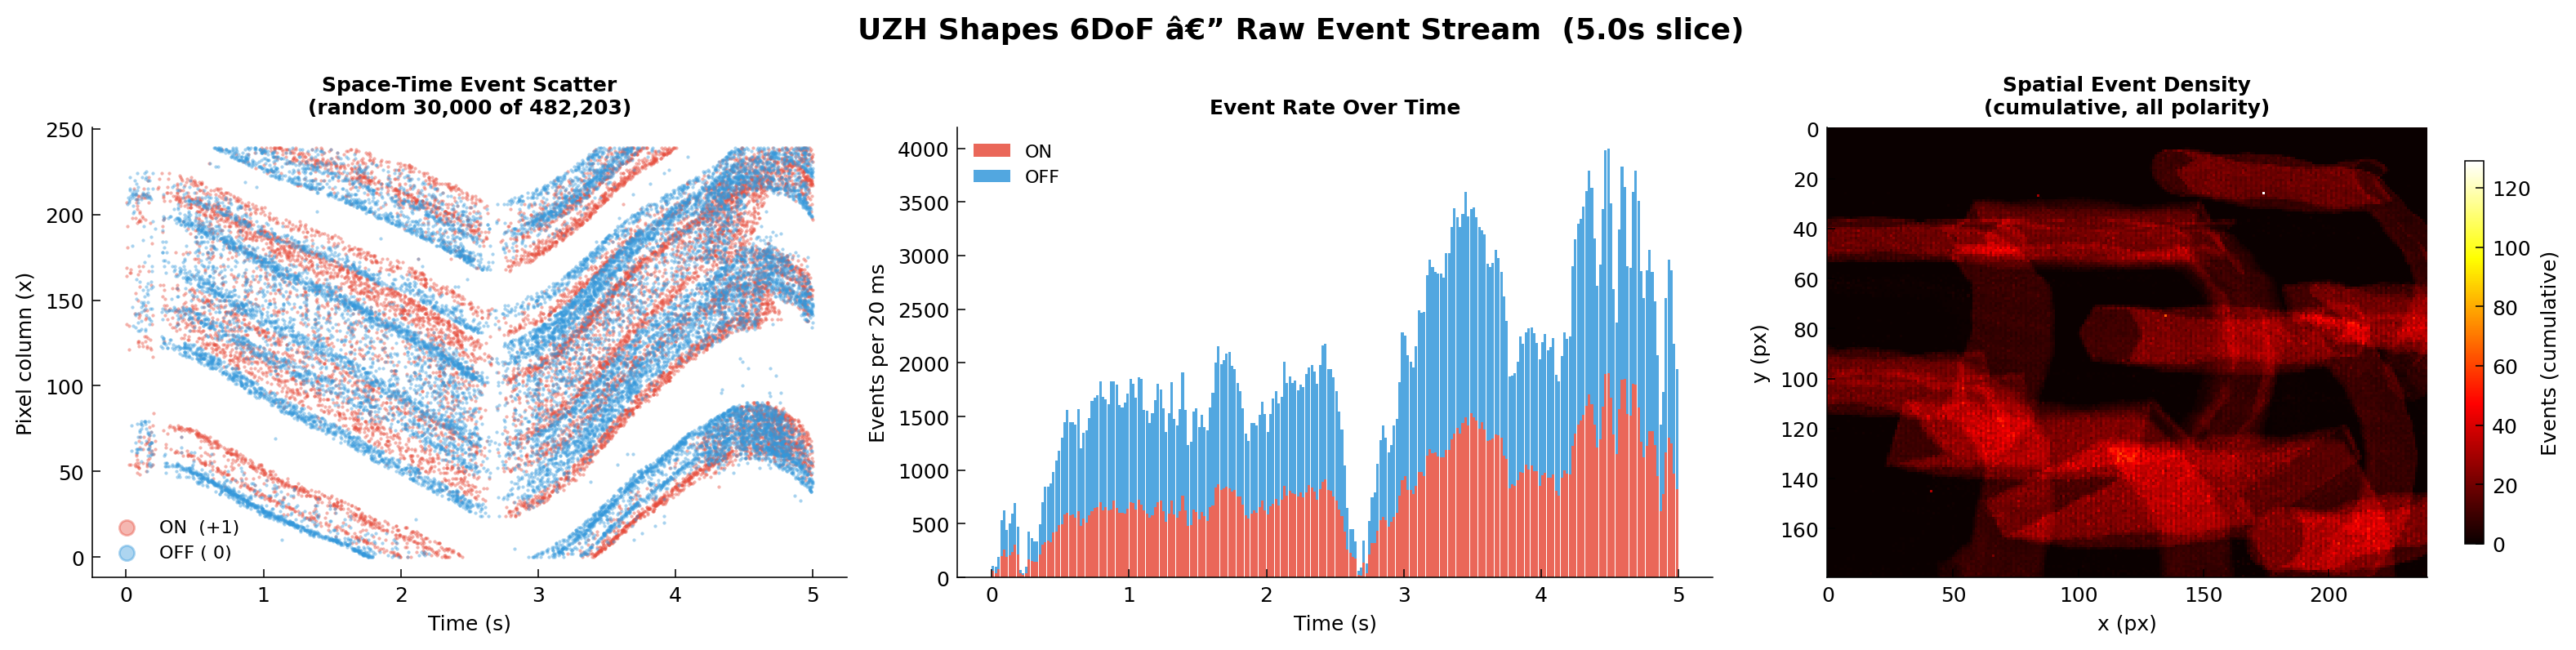

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# â”€â”€ 1. Space-time scatter (sample for speed) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
N_samp = min(30_000, len(t_ev))
rng = np.random.default_rng(0)
idx = np.sort(rng.choice(len(t_ev), N_samp, replace=False))
pos_mask = p_ev[idx] == 1
axes[0].scatter(t_ev[idx[pos_mask]],  x_ev[idx[pos_mask]],
                s=0.3, c='#e74c3c', alpha=0.4, label='ON  (+1)')
axes[0].scatter(t_ev[idx[~pos_mask]], x_ev[idx[~pos_mask]],
                s=0.3, c='#3498db', alpha=0.4, label='OFF ( 0)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Pixel column (x)')
axes[0].set_title(f'Space-Time Event Scatter\n(random {N_samp:,} of {len(t_ev):,})')
axes[0].legend(fontsize=8, markerscale=12)

# â”€â”€ 2. Event rate histogram â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
BIN_MS = 20   # ms bins
bin_edges = np.arange(0, T_MAX + BIN_MS/1000, BIN_MS/1000)
cnt_on,  _ = np.histogram(t_ev[p_ev == 1], bins=bin_edges)
cnt_off, _ = np.histogram(t_ev[p_ev == 0], bins=bin_edges)
bcentres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
axes[1].bar(bcentres, cnt_on,  width=BIN_MS/1100, color='#e74c3c', alpha=0.85, label='ON')
axes[1].bar(bcentres, cnt_off, width=BIN_MS/1100, color='#3498db', alpha=0.85,
            bottom=cnt_on, label='OFF')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel(f'Events per {BIN_MS} ms')
axes[1].set_title('Event Rate Over Time')
axes[1].legend(fontsize=8)

# â”€â”€ 3. Cumulative spatial density â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
density = np.zeros((H_sensor, W_sensor), dtype=np.float32)
np.add.at(density, (y_ev.clip(0, H_sensor-1), x_ev.clip(0, W_sensor-1)), 1)
im = axes[2].imshow(density, cmap='hot', origin='upper')
plt.colorbar(im, ax=axes[2], shrink=0.85, label='Events (cumulative)')
axes[2].set_title('Spatial Event Density\n(cumulative, all polarity)')
axes[2].set_xlabel('x (px)'); axes[2].set_ylabel('y (px)')

plt.suptitle(f'UZH Shapes 6DoF â€” Raw Event Stream  ({T_MAX}s slice)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 4 â€” Accumulate Events into Frames
SSP-SLAM (and most vision algorithms) operate on fixed-rate frames.  
We bin events into 50 ms windows using `accumulate_events_to_frames`, setting  
each fired pixel to 255 so the result looks like a grayscale image.

Accumulated 100 frames  (50 ms windows)
Frame shape : (100, 180, 240)
Time range  : 0.050s â€” 5.000s


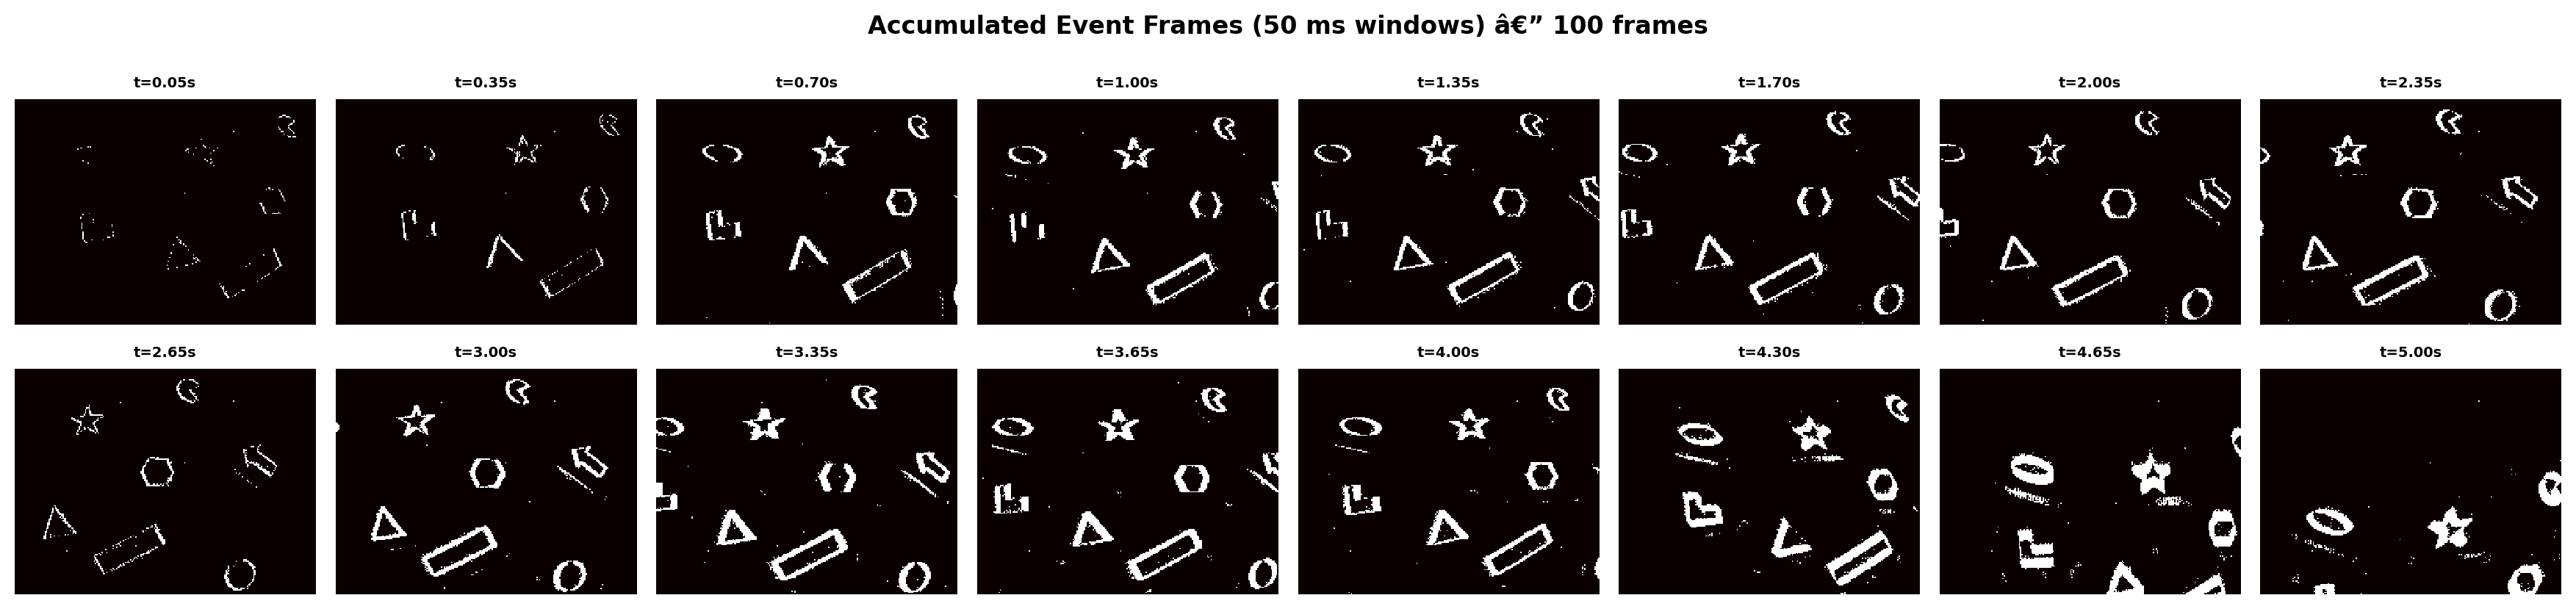

In [17]:
from sspslam.perception.event_dataset_parser import accumulate_events_to_frames

DT_WINDOW = 0.05   # 50 ms per frame â†’ ~20 fps

event_frames, frame_times = accumulate_events_to_frames(
    t_ev, x_ev, y_ev, (p_ev == 1).astype(np.uint8),
    DT_WINDOW, W_sensor, H_sensor
)
N_frames = len(event_frames)

print(f"Accumulated {N_frames} frames  ({DT_WINDOW*1000:.0f} ms windows)")
print(f"Frame shape : {event_frames.shape}")
print(f"Time range  : {frame_times[0]:.3f}s â€” {frame_times[-1]:.3f}s")

# Show a grid
n_show  = min(N_frames, 16)
show_fi = np.linspace(0, N_frames - 1, n_show, dtype=int)
cols, rows = 8, (n_show + 7) // 8

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
axes = axes.flatten()
for i, fi in enumerate(show_fi):
    axes[i].imshow(event_frames[fi], cmap='hot', vmin=0, vmax=255, origin='upper')
    axes[i].axis('off')
    axes[i].set_title(f't={frame_times[fi]:.2f}s', fontsize=7)
for ax in axes[n_show:]: ax.axis('off')

plt.suptitle(f'Accumulated Event Frames ({DT_WINDOW*1000:.0f} ms windows) â€” {N_frames} frames', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 5 â€” Ground-Truth Trajectory
Vicon motion-capture provides 6DoF pose at ~200 Hz.  
We use the **xâ€“z plane** (overhead view) as the 2D SLAM map,  
normalise positions to \[âˆ’1, 1\], and derive velocity by finite-differencing.

> **Why use GT velocities?**  
> Monocular visual odometry suffers from **scale ambiguity** â€” the absolute scale  
> of motion cannot be recovered from a single camera without depth information.  
> Using GT velocities sidesteps this and lets us evaluate the SLAM memory cleanly.

GT poses : 11862  time span 59.72s
x range  : [3.520, 4.670] m
y range  : [1.234, 2.099] m  (vertical)
z range  : [1.176, 1.855] m

Normalised path  x: [-0.27, 0.27]
Normalised path  z: [-1.00, 1.00]
Velocity scale factor: 3.1702 (normalised units/s)


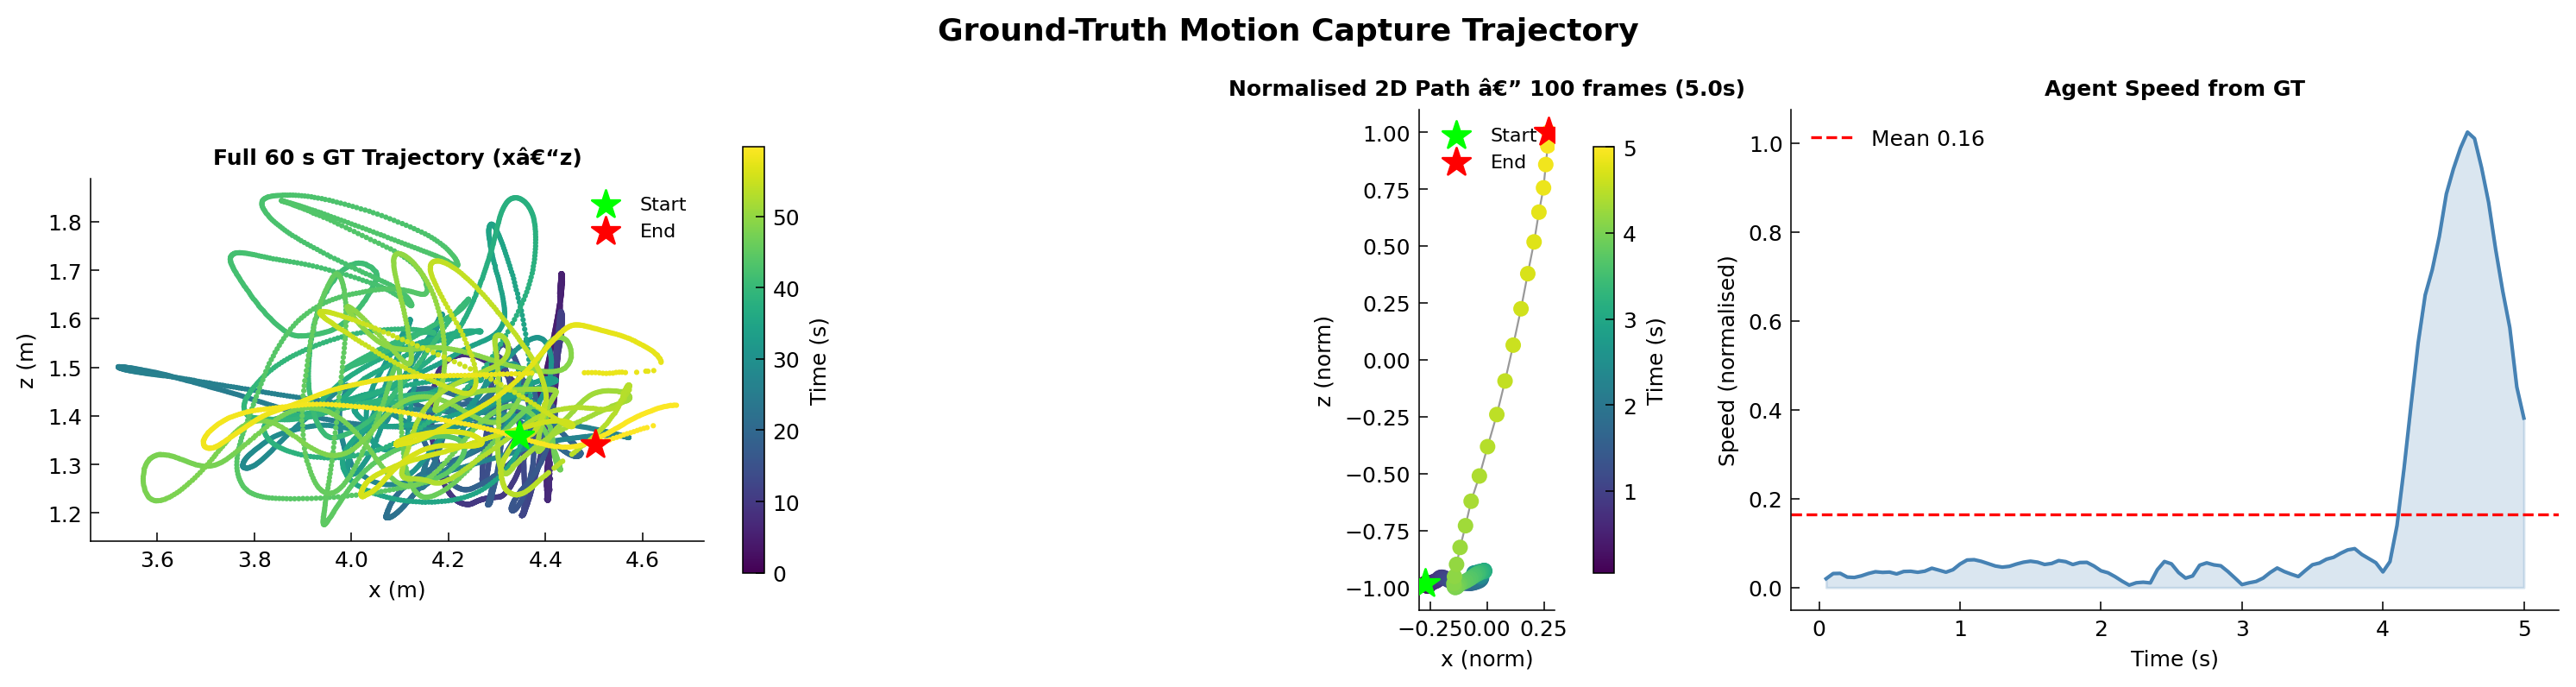

In [18]:
from sspslam.perception.event_dataset_parser import load_groundtruth_txt, interpolate_groundtruth

gt_path = os.path.join(DATA_DIR, "groundtruth.txt")
gt_t_abs, gt_pos, gt_quat = load_groundtruth_txt(gt_path)
gt_t = gt_t_abs - gt_t_abs[0]   # zero-relative

print(f"GT poses : {len(gt_t)}  time span {gt_t[-1]:.2f}s")
print(f"x range  : [{gt_pos[:,0].min():.3f}, {gt_pos[:,0].max():.3f}] m")
print(f"y range  : [{gt_pos[:,1].min():.3f}, {gt_pos[:,1].max():.3f}] m  (vertical)")
print(f"z range  : [{gt_pos[:,2].min():.3f}, {gt_pos[:,2].max():.3f}] m")

# Align GT time base to events  (event t=0 corresponds to t0_abs in GT absolute clock)
# frame_times are relative to first event; GT relative to its own first sample.
# Both are near-simultaneous recordings, so the small offset (~44ms) is negligible.
gt_pos_frames = interpolate_groundtruth(gt_t, gt_pos, frame_times)  # (N_frames, 3)

# Project to 2D overhead (x, z) â€” y is the vertical axis in this dataset
path_2d_raw = gt_pos_frames[:, [0, 2]]   # (N_frames, 2)

# Normalise to [-1, 1] preserving aspect ratio
p_min, p_max = path_2d_raw.min(axis=0), path_2d_raw.max(axis=0)
p_range  = max((p_max - p_min).max(), 1e-6)
p_centre = 0.5 * (p_min + p_max)
path_norm = (path_2d_raw - p_centre) / (0.5 * p_range)

# Velocity from GT: finite differences, then normalise max to 1
vel_norm_raw = np.gradient(path_norm, axis=0) / DT_WINDOW
vel_scale    = np.abs(vel_norm_raw).max() + 1e-8
vel_norm     = vel_norm_raw / vel_scale

print(f"\nNormalised path  x: [{path_norm[:,0].min():.2f}, {path_norm[:,0].max():.2f}]")
print(f"Normalised path  z: [{path_norm[:,1].min():.2f}, {path_norm[:,1].max():.2f}]")
print(f"Velocity scale factor: {vel_scale:.4f} (normalised units/s)")

# â”€â”€ Plots â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full GT trajectory xâ€“z
sc = axes[0].scatter(gt_pos[:,0], gt_pos[:,2], c=gt_t, cmap='viridis', s=1.5)
axes[0].scatter(*gt_pos[0,[0,2]], s=150, c='lime', marker='*', zorder=5, label='Start')
axes[0].scatter(*gt_pos[-1,[0,2]], s=150, c='red', marker='*', zorder=5, label='End')
plt.colorbar(sc, ax=axes[0], label='Time (s)', shrink=0.85)
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('z (m)')
axes[0].set_aspect('equal')
axes[0].set_title('Full 60 s GT Trajectory (xâ€“z)')
axes[0].legend(fontsize=8)

# Normalised path for our 5 s slice
sc = axes[1].scatter(path_norm[:,0], path_norm[:,1],
                     c=frame_times, cmap='viridis', s=30, zorder=3)
axes[1].plot(path_norm[:,0], path_norm[:,1], 'k-', lw=0.8, alpha=0.4)
axes[1].scatter(*path_norm[0],  s=150, c='lime', marker='*', zorder=5, label='Start')
axes[1].scatter(*path_norm[-1], s=150, c='red',  marker='*', zorder=5, label='End')
plt.colorbar(sc, ax=axes[1], label='Time (s)', shrink=0.85)
axes[1].set_xlabel('x (norm)'); axes[1].set_ylabel('z (norm)')
axes[1].set_aspect('equal')
axes[1].set_title(f'Normalised 2D Path â€” {N_frames} frames ({T_MAX}s)')
axes[1].legend(fontsize=8)

# Speed
speed = np.linalg.norm(vel_norm, axis=1)
axes[2].plot(frame_times, speed, 'steelblue', lw=1.5)
axes[2].axhline(speed.mean(), c='red', ls='--', lw=1.2, label=f'Mean {speed.mean():.2f}')
axes[2].fill_between(frame_times, 0, speed, alpha=0.2, color='steelblue')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Speed (normalised)')
axes[2].set_title('Agent Speed from GT')
axes[2].legend(fontsize=9)

plt.suptitle('Ground-Truth Motion Capture Trajectory', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 6 â€” Landmark Tracking
We detect Shi-Tomasi corner features in each accumulated event frame and track them  
with Lucas-Kanade optical flow. The most temporally stable tracks become our **landmarks** â€”  
persistent scene features the SLAM network can build a memory around.

Running landmark tracking over 100 frames...
  Done in 0.1s

Top 4 landmarks (track id â†’ frames seen):
  Track   5 : 100/100 frames  (100%)
  Track   8 : 100/100 frames  (100%)
  Track   9 : 100/100 frames  (100%)
  Track  10 : 100/100 frames  (100%)


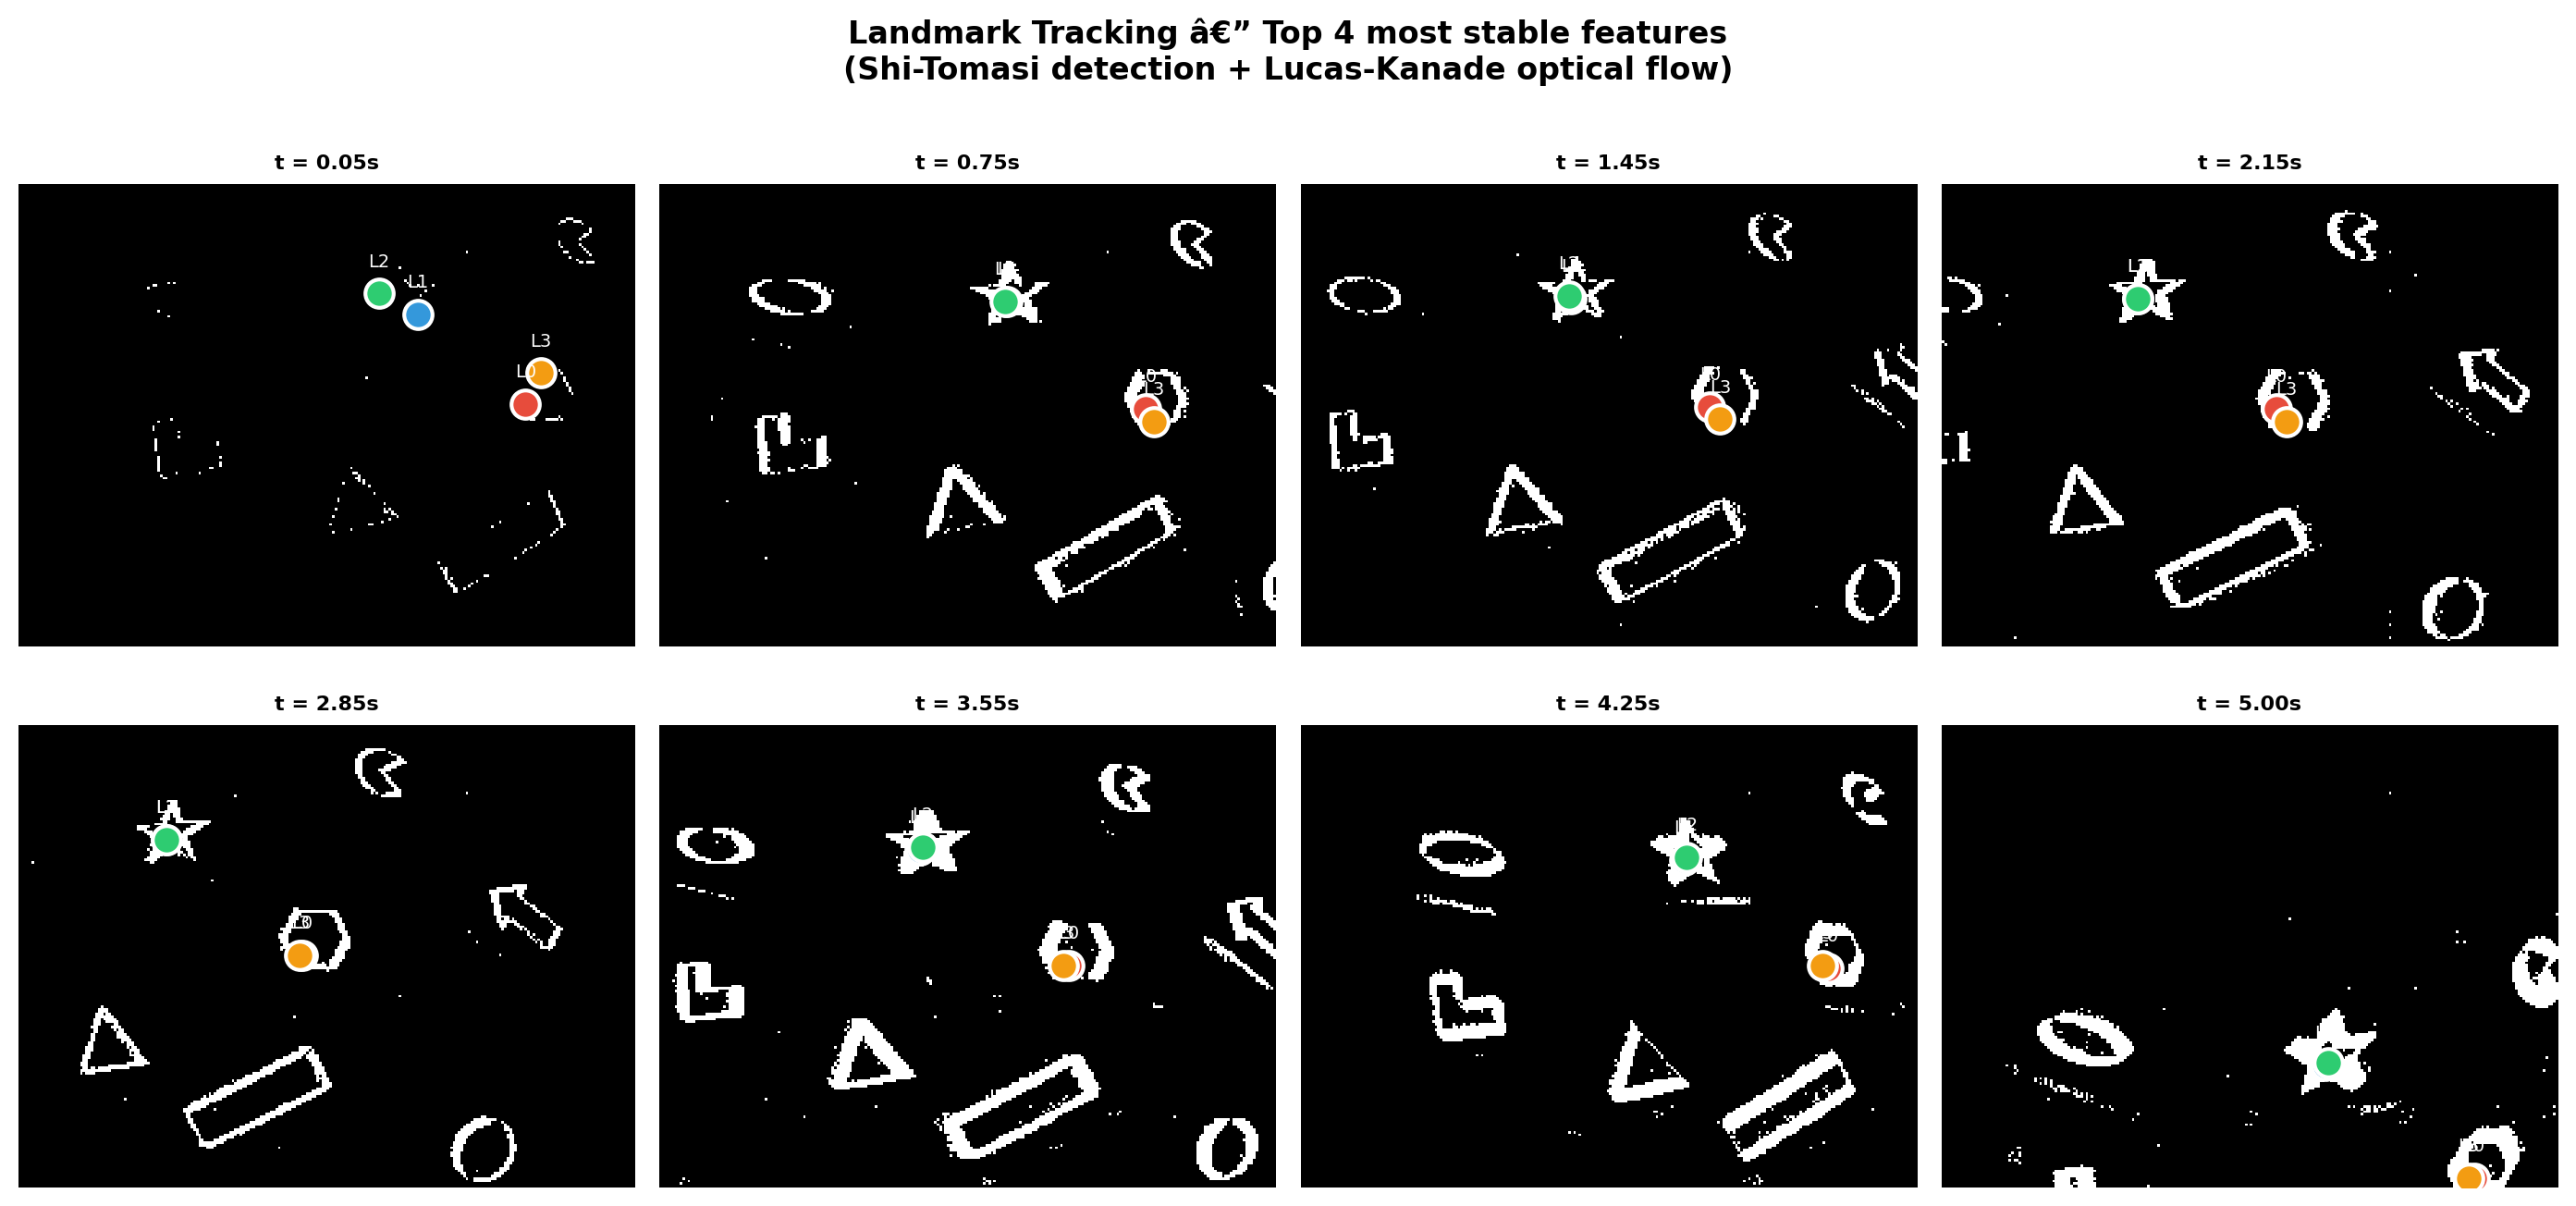

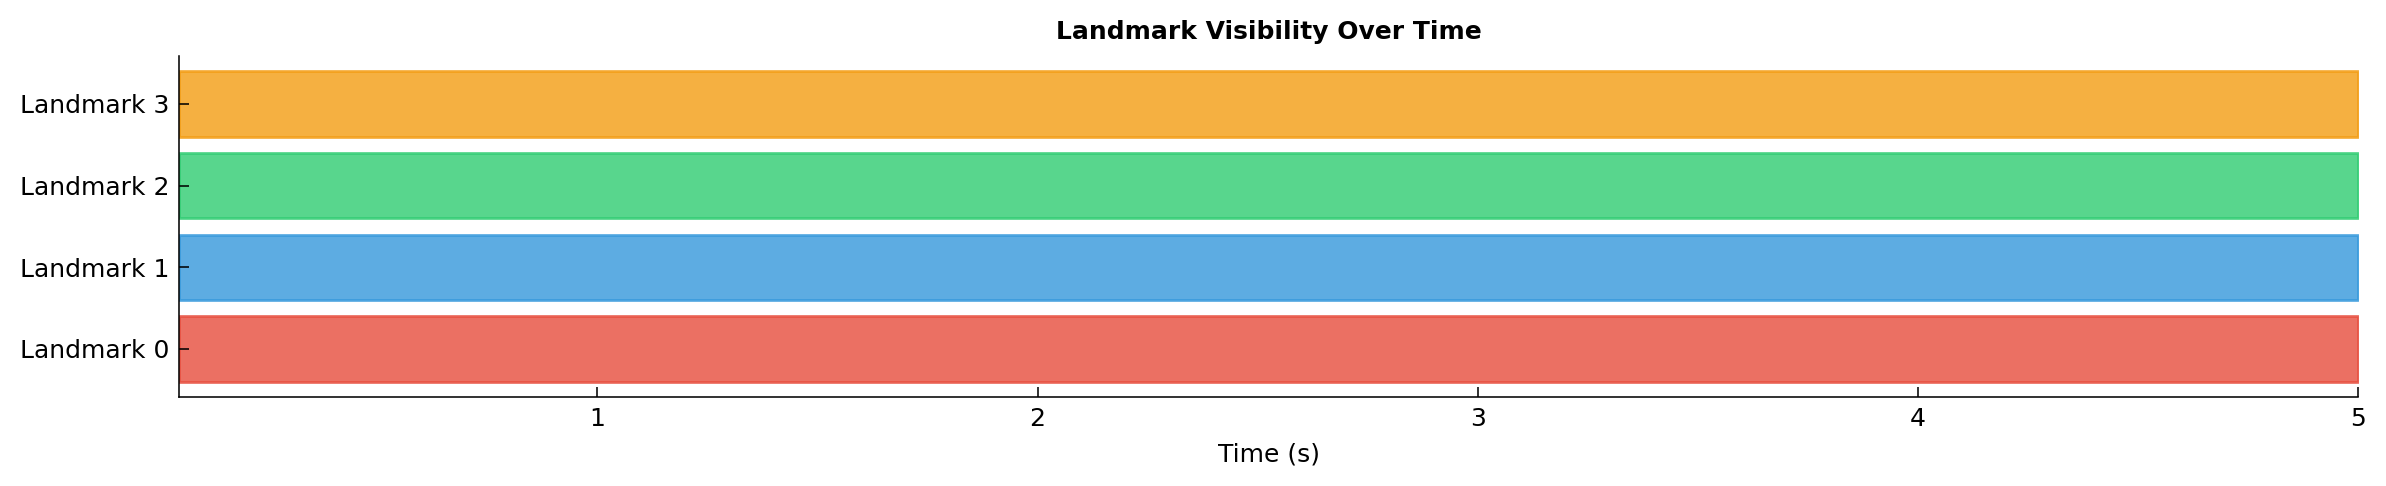

In [19]:
import cv2
from sspslam.perception.event_vision_adapter import EventVisionAdapter

N_LANDMARKS = 4        # number of landmarks to hand to SLAM
VIEW_RADIUS  = 1.5     # normalised spatial units
FOV_X_DEG   = 50.0     # approx horizontal FOV of DAVIS240C

adapter = EventVisionAdapter(
    max_landmarks=24,
    view_radius=VIEW_RADIUS,
    fov_x=FOV_X_DEG,
    backend='classic'
)

print(f"Running landmark tracking over {N_frames} frames...")
t_track = time.time()
_, vec_arr_all, _ = adapter.process_dataset(
    event_frames,
    agent_velocities=vel_norm,   # use GT so no VO needed
    landmark_depths=None
)
print(f"  Done in {time.time()-t_track:.1f}s")

# Identify top-N landmarks by stability
track_counts = {}
for fdata in adapter.history:
    for tid in fdata:
        track_counts[tid] = track_counts.get(tid, 0) + 1
top_ids = sorted(track_counts, key=track_counts.get, reverse=True)[:N_LANDMARKS]

print(f"\nTop {N_LANDMARKS} landmarks (track id â†’ frames seen):")
for tid in top_ids:
    pct = 100 * track_counts[tid] / N_frames
    print(f"  Track {tid:3d} : {track_counts[tid]:3d}/{N_frames} frames  ({pct:.0f}%)")

# Build per-landmark pixel-position matrix for visualisation
# shape (N_frames, N_LANDMARKS, 2) â€” NaN where not visible
track_px = np.full((N_frames, N_LANDMARKS, 2), np.nan)
for t_i, fdata in enumerate(adapter.history):
    for lm_i, tid in enumerate(top_ids):
        if tid in fdata and 'pos' in fdata[tid]:
            track_px[t_i, lm_i] = fdata[tid]['pos']

# Build vec_arr for top-N landmarks  (N_frames, N_LANDMARKS, 2)
vec_arr = np.zeros((N_frames, N_LANDMARKS, 2))
for t_i, fdata in enumerate(adapter.history):
    for lm_i, tid in enumerate(top_ids):
        if tid in fdata:
            vec_arr[t_i, lm_i] = fdata[tid]['vector']
        else:
            vec_arr[t_i, lm_i] = VIEW_RADIUS * 2   # out of range = not visible

# â”€â”€ Visualise tracks on event frames â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
n_vis = min(N_frames, 8)
vis_fi = np.linspace(0, N_frames - 1, n_vis, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for i, fi in enumerate(vis_fi):
    ax = axes[i]
    ax.imshow(event_frames[fi], cmap='gray', vmin=0, vmax=255, origin='upper')
    for lm_i in range(N_LANDMARKS):
        if not np.any(np.isnan(track_px[fi, lm_i])):
            u, v = track_px[fi, lm_i]
            ax.plot(u, v, 'o', color=COLORS[lm_i], markersize=11,
                    markeredgecolor='white', markeredgewidth=1.5)
            ax.annotate(f'L{lm_i}', (u, v), fontsize=7, color='white',
                        ha='center', va='bottom',
                        xytext=(0, 9), textcoords='offset points')
    ax.axis('off')
    ax.set_title(f't = {frame_times[fi]:.2f}s', fontsize=8)

plt.suptitle(f'Landmark Tracking â€” Top {N_LANDMARKS} most stable features\n'
             f'(Shi-Tomasi detection + Lucas-Kanade optical flow)',
             fontsize=12)
plt.tight_layout()
plt.show()

# â”€â”€ Landmark visibility over time â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(12, 2.5))
for lm_i in range(N_LANDMARKS):
    visible = ~np.any(np.isnan(track_px[:, lm_i]), axis=1)
    ax.fill_between(frame_times, lm_i + 0.1, lm_i + 0.9,
                    where=visible, color=COLORS[lm_i], alpha=0.8, label=f'L{lm_i}')
ax.set_yticks(np.arange(N_LANDMARKS) + 0.5)
ax.set_yticklabels([f'Landmark {i}' for i in range(N_LANDMARKS)])
ax.set_xlabel('Time (s)')
ax.set_title('Landmark Visibility Over Time')
ax.set_xlim(frame_times[0], frame_times[-1])
plt.tight_layout()
plt.show()

---
## Section 7 â€” Per-Landmark Feature Extraction
For each tracked landmark we extract a **HOG descriptor** from a patch  
around its pixel position. HOG captures local orientation structure and works  
on binary event frames because fired pixels (value 255) create detectable gradients.

We then blend each patch HOG with a **stable random identity vector** seeded by  
the landmark's track ID. This guarantees that the SLAM network can distinguish  
landmarks even when they share similar event-frame context (common on event cameras).

HOG patch descriptor dim: 900  (48Ã—48 px, 9 orientations)
Feature array: (100, 4, 900)  (frames Ã— landmarks Ã— feat_dim)
Max off-diagonal similarity: 0.618  (OK)


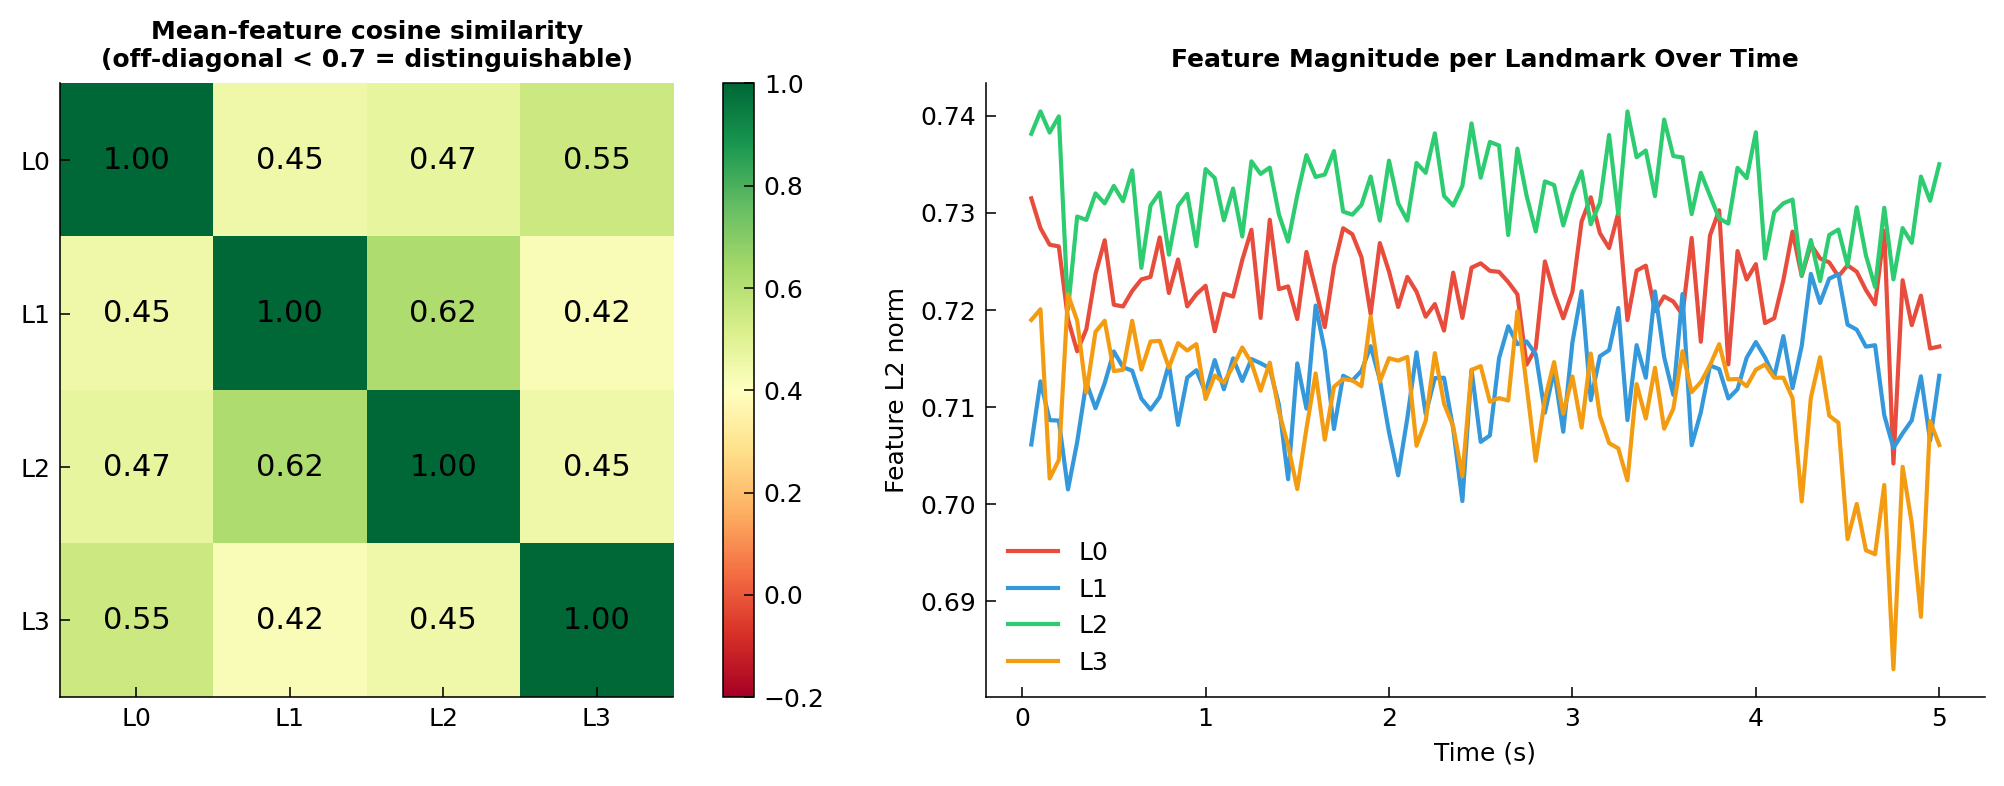

In [20]:
from skimage.feature import hog
from skimage.transform import resize as sk_resize

PATCH_PX = 48    # crop size around each landmark (pixels)
HOG_ORI  = 9
HOG_PPC  = (8, 8)
HOG_CPB  = (2, 2)

def _patch_hog(frame, cx, cy, patch_size=PATCH_PX):
    """HOG descriptor from a square patch centred at (cx, cy)."""
    H, W  = frame.shape[:2]
    half  = patch_size // 2
    x1, y1 = max(0, int(cx) - half), max(0, int(cy) - half)
    x2, y2 = min(W, int(cx) + half), min(H, int(cy) + half)
    patch  = frame[y1:y2, x1:x2].astype(np.float32) / 255.0
    if patch.size == 0:
        patch = np.zeros((patch_size, patch_size), dtype=np.float32)
    patch_r = sk_resize(patch, (patch_size, patch_size), anti_aliasing=False)
    return hog(patch_r, orientations=HOG_ORI, pixels_per_cell=HOG_PPC,
               cells_per_block=HOG_CPB, visualize=False)

# Get HOG dim from a test patch
test_feat = _patch_hog(event_frames[0], W_sensor//2, H_sensor//2)
feat_dim  = test_feat.shape[0]
print(f"HOG patch descriptor dim: {feat_dim}  ({PATCH_PX}Ã—{PATCH_PX} px, {HOG_ORI} orientations)")

# Extract per-landmark, per-frame HOG features
feat_arr = np.zeros((N_frames, N_LANDMARKS, feat_dim), dtype=np.float32)
for t_i in range(N_frames):
    for lm_i in range(N_LANDMARKS):
        if not np.any(np.isnan(track_px[t_i, lm_i])):
            u, v = track_px[t_i, lm_i]
            feat_arr[t_i, lm_i] = _patch_hog(event_frames[t_i], u, v)

# Blend with per-landmark identity vector
for lm_i in range(N_LANDMARKS):
    rng_id = np.random.default_rng(seed=top_ids[lm_i])
    identity = rng_id.standard_normal(feat_dim).astype(np.float32)
    identity /= np.linalg.norm(identity)
    for t_i in range(N_frames):
        f = feat_arr[t_i, lm_i]
        norm_f = np.linalg.norm(f)
        if norm_f > 1e-8:
            f /= norm_f
        feat_arr[t_i, lm_i] = 0.6 * f + 0.4 * identity

print(f"Feature array: {feat_arr.shape}  (frames Ã— landmarks Ã— feat_dim)")

# â”€â”€ Similarity matrix â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
mean_feats = feat_arr.mean(axis=0)   # (N_LANDMARKS, feat_dim)
norms = np.linalg.norm(mean_feats, axis=1, keepdims=True)
mean_norm = mean_feats / np.maximum(norms, 1e-8)
sim_mat = mean_norm @ mean_norm.T

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(sim_mat, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
for i in range(N_LANDMARKS):
    for j in range(N_LANDMARKS):
        axes[0].text(j, i, f"{sim_mat[i,j]:.2f}", ha='center', va='center', fontsize=11)
axes[0].set_xticks(range(N_LANDMARKS)); axes[0].set_xticklabels([f'L{i}' for i in range(N_LANDMARKS)])
axes[0].set_yticks(range(N_LANDMARKS)); axes[0].set_yticklabels([f'L{i}' for i in range(N_LANDMARKS)])
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Mean-feature cosine similarity\n(off-diagonal < 0.7 = distinguishable)")

max_off = sim_mat[~np.eye(N_LANDMARKS, dtype=bool)].max()
print(f"Max off-diagonal similarity: {max_off:.3f}  ({'OK' if max_off < 0.7 else 'WARNING: too similar'})")

# Feature norm over time
for lm_i in range(N_LANDMARKS):
    norms_t = np.linalg.norm(feat_arr[:, lm_i, :], axis=1)
    axes[1].plot(frame_times, norms_t, label=f'L{lm_i}', color=COLORS[lm_i], lw=1.5)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Feature L2 norm')
axes[1].set_title('Feature Magnitude per Landmark Over Time')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 8 â€” SSP Position Encoding
Spatial Semantic Pointers (SSPs) represent continuous 2D positions as high-dimensional  
vectors whose **dot-product decays smoothly with distance** â€” analogous to place cells  
and grid cells in the hippocampal-entorhinal circuit.

Features are projected to the same SSP space via `ImageFeatureEncoder`  
(a random projection satisfying the Johnson-Lindenstrauss lemma).

SSP space: domain=2D  ssp_dim=97


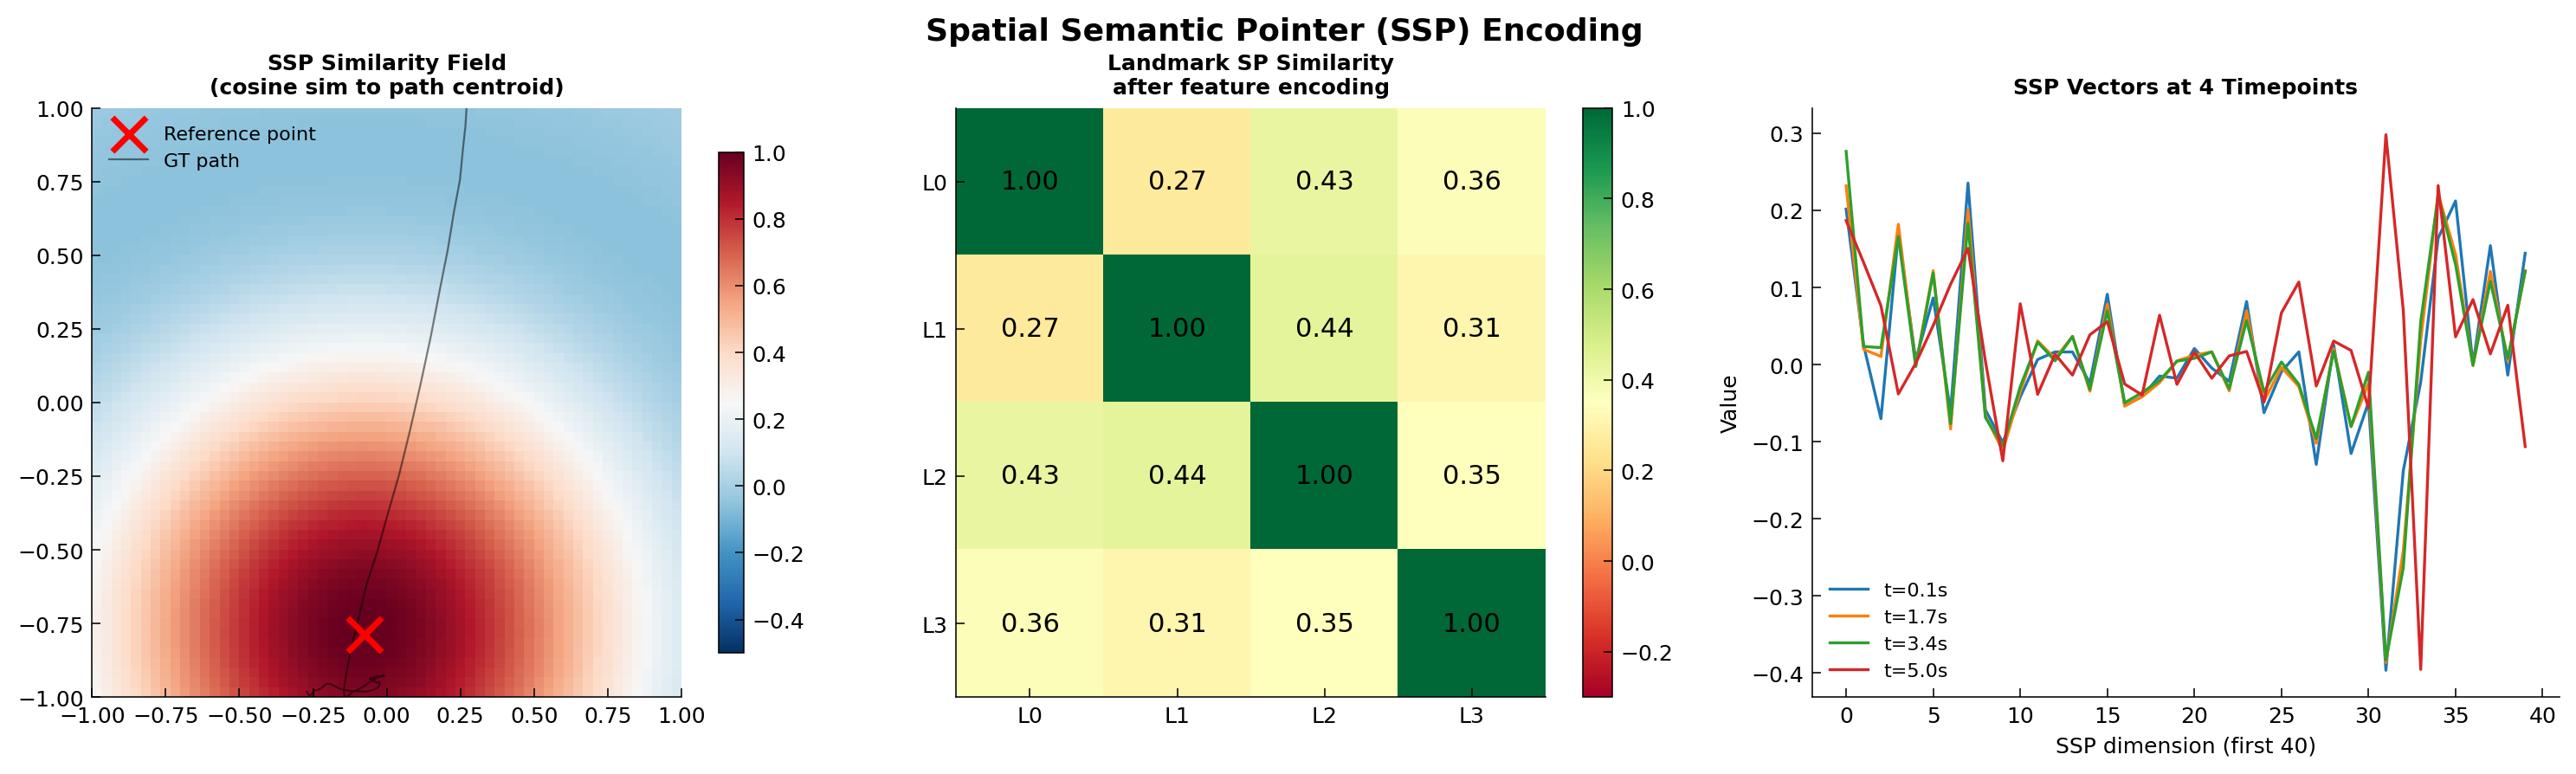

In [21]:
from sspslam import HexagonalSSPSpace
from sspslam.perception import ImageFeatureEncoder

SSP_DIM = 97

ssp_space = HexagonalSSPSpace(
    domain_dim=2, ssp_dim=SSP_DIM,
    domain_bounds=np.array([[-1, 1], [-1, 1]]),
    seed=SEED
)
ssp_dim = ssp_space.ssp_dim
print(f"SSP space: domain=2D  ssp_dim={ssp_dim}")

encoder = ImageFeatureEncoder(feat_dim=feat_dim, ssp_dim=ssp_dim, seed=SEED)

# Encode GT path as SSPs
path_ssps = ssp_space.encode(path_norm)   # (N_frames, ssp_dim)

# Mean appearance SP per landmark
object_sps = np.vstack([
    encoder.encode(feat_arr[:, lm_i, :].mean(axis=0)[None]).squeeze()
    for lm_i in range(N_LANDMARKS)
])
sp_sim = object_sps @ object_sps.T

# Query grid for visualisation
RES = 60
xs = np.linspace(-1, 1, RES); ys = np.linspace(-1, 1, RES)
xx, yy = np.meshgrid(xs, ys)
grid_pts  = np.stack([xx.ravel(), yy.ravel()], axis=1)
grid_ssps = ssp_space.encode(grid_pts)   # (RESÂ², ssp_dim)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Similarity field around path centre
ref_ssp = ssp_space.encode(path_norm.mean(axis=0)[None]).squeeze()
sims_grid = (grid_ssps @ ref_ssp).reshape(RES, RES)
im = axes[0].imshow(sims_grid, origin='lower', extent=[-1,1,-1,1],
                    cmap='RdBu_r', vmin=-0.5, vmax=1.0)
axes[0].scatter(*path_norm.mean(axis=0), s=200, c='red', marker='x',
                linewidths=2.5, zorder=5, label='Reference point')
axes[0].plot(path_norm[:,0], path_norm[:,1], 'k-', lw=0.8, alpha=0.5, label='GT path')
plt.colorbar(im, ax=axes[0], shrink=0.85)
axes[0].set_title('SSP Similarity Field\n(cosine sim to path centroid)')
axes[0].legend(fontsize=8)

# Object SP similarity
im2 = axes[1].imshow(sp_sim, cmap='RdYlGn', vmin=-0.3, vmax=1.0)
for i in range(N_LANDMARKS):
    for j in range(N_LANDMARKS):
        axes[1].text(j, i, f"{sp_sim[i,j]:.2f}", ha='center', va='center', fontsize=11)
axes[1].set_xticks(range(N_LANDMARKS)); axes[1].set_xticklabels([f'L{i}' for i in range(N_LANDMARKS)])
axes[1].set_yticks(range(N_LANDMARKS)); axes[1].set_yticklabels([f'L{i}' for i in range(N_LANDMARKS)])
plt.colorbar(im2, ax=axes[1])
axes[1].set_title('Landmark SP Similarity\nafter feature encoding')

# SSP vector components
for i, t_check in enumerate([0, N_frames//3, 2*N_frames//3, -1]):
    axes[2].plot(path_ssps[t_check, :40], lw=1.2,
                 label=f't={frame_times[t_check]:.1f}s')
axes[2].set_xlabel('SSP dimension (first 40)')
axes[2].set_ylabel('Value')
axes[2].set_title('SSP Vectors at 4 Timepoints')
axes[2].legend(fontsize=8)

plt.suptitle('Spatial Semantic Pointer (SSP) Encoding', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 9 â€” Build SLAM Input Functions
The Nengo simulation runs at `dt = 1 ms`.  We need to interpolate the  
frame-rate data (50 ms) to the simulation timestep using linear stretching,  
then wrap everything in time-indexed Python functions that Nengo nodes can call.

In [22]:
from sspslam.networks import get_slam_input_functions_from_features
import sspslam as ss

T_SIM = 10.0    # simulation time (seconds) â€” data is stretched to fill this
dt    = 0.001
n_sim = int(T_SIM / dt)

def _stretch(arr, n_out):
    """Linearly interpolate arr (T, ...) to n_out timesteps."""
    t0 = np.linspace(0, 1, arr.shape[0])
    t1 = np.linspace(0, 1, n_out)
    if arr.ndim == 2:
        return np.stack([np.interp(t1, t0, arr[:, d]) for d in range(arr.shape[1])], axis=1)
    out = np.zeros((n_out, arr.shape[1], arr.shape[2]))
    for i in range(arr.shape[1]):
        for j in range(arr.shape[2]):
            out[:, i, j] = np.interp(t1, t0, arr[:, i, j])
    return out

path_sim = _stretch(path_norm, n_sim)   # (n_sim, 2)
vel_sim  = _stretch(vel_norm,  n_sim)   # (n_sim, 2)
vec_sim  = _stretch(vec_arr,   n_sim)   # (n_sim, N_LANDMARKS, 2)
feat_sim = _stretch(feat_arr,  n_sim)   # (n_sim, N_LANDMARKS, feat_dim)

print(f"Stretched arrays to {n_sim:,} steps  (T_SIM={T_SIM}s, dt={dt}s)")
print(f"  path_sim : {path_sim.shape}")
print(f"  vel_sim  : {vel_sim.shape}")
print(f"  vec_sim  : {vec_sim.shape}")
print(f"  feat_sim : {feat_sim.shape}")

fns = get_slam_input_functions_from_features(
    ssp_space, encoder,
    vel_sim, vec_sim, feat_sim,
    view_rad=VIEW_RADIUS, dt=dt
)
(velocity_func, vel_scaling_factor,
 is_landmark_in_view, landmark_id_func,
 landmark_sp_func, landmark_vec_func,
 landmark_vecssp_func) = fns

# Build landmark SP space
lm_sps   = encoder.encode(feat_sim.mean(axis=0))   # (N_LANDMARKS, ssp_dim)
lm_space = ss.SPSpace(N_LANDMARKS, ssp_dim, seed=SEED, vectors=lm_sps)
real_ssp = ssp_space.encode(path_sim)              # (n_sim, ssp_dim)

print(f"\nvel_scaling_factor : {vel_scaling_factor:.4f}")
print(f"lm_space.vectors   : {lm_space.vectors.shape}")

# Spot-check
for t_check in [0.0, T_SIM/4, T_SIM/2, 3*T_SIM/4]:
    v = velocity_func(t_check)
    s = landmark_sp_func(t_check)
    assert v.shape == (2,)
    assert s.shape == (ssp_dim,)
print("Input function spot-checks PASSED")

Stretched arrays to 10,000 steps  (T_SIM=10.0s, dt=0.001s)
  path_sim : (10000, 2)
  vel_sim  : (10000, 2)
  vec_sim  : (10000, 4, 2)
  feat_sim : (10000, 4, 900)

vel_scaling_factor : 0.3111
lm_space.vectors   : (4, 97)
Input function spot-checks PASSED


---
## Section 10 â€” Run Nengo Spiking SLAM Network
The `SLAMNetwork` is a biologically-inspired neural architecture that combines:
- **Path integrator** â€” integrates velocity into a running SSP position estimate  
- **Associative memory** â€” Voja + PES learning rules bind landmark identities to locations  

This runs on CPU with `nengo.Simulator`. Expect ~60â€“90 s.

In [23]:
import nengo
import sspslam as ss
from sspslam.networks import SLAMNetwork

model = nengo.Network(seed=SEED)
with model:
    # â”€â”€ Input nodes â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    vel_node   = nengo.Node(velocity_func)
    init_node  = nengo.Node(
        lambda t: real_ssp[min(int(t/dt), n_sim-1)] if t < 0.05 else np.zeros(ssp_dim)
    )
    vec_node   = nengo.Node(landmark_vecssp_func)
    id_node    = nengo.Node(landmark_sp_func)
    view_node  = nengo.Node(is_landmark_in_view)

    # â”€â”€ SLAM network â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    slam = SLAMNetwork(
        ssp_space, lm_space, VIEW_RADIUS, N_LANDMARKS,
        pi_n_neurons=300, mem_n_neurons=500, circonv_n_neurons=70,
        tau_pi=0.05, update_thres=0.2,
        vel_scaling_factor=vel_scaling_factor,
        shift_rate=0.1,
        voja_learning_rate=1e-4,
        pes_learning_rate=5e-3,
        intercept=0.1,
        clean_up_method='grid',
        voja=True,
        seed=SEED,
    )

    # â”€â”€ Connections â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    nengo.Connection(vel_node,  slam.velocity_input,       synapse=None)
    nengo.Connection(init_node, slam.pathintegrator.input, synapse=None)
    nengo.Connection(vec_node,  slam.landmark_vec_ssp,     synapse=None)
    nengo.Connection(id_node,   slam.landmark_id_input,    synapse=None)
    nengo.Connection(view_node, slam.no_landmark_in_view,  synapse=None)

    # â”€â”€ Probes â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    pi_probe  = nengo.Probe(slam.pathintegrator.output, synapse=0.05)
    mem_probe = nengo.Probe(slam.assomemory.conn_out, 'weights', sample_every=T_SIM)

print(f"Running Nengo SLAM simulation  (T={T_SIM}s, dt={dt}s, CPU)...")
t_run_start = time.time()
with nengo.Simulator(model, dt=dt, progress_bar=True) as sim:
    sim.run(T_SIM)
elapsed = time.time() - t_run_start
print(f"\nCompleted in {elapsed:.1f}s")

# â”€â”€ Post-process outputs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
slam_ssp_out = sim.data[pi_probe]            # (n_sim, ssp_dim)
mem_weights  = sim.data[mem_probe][-1].T     # (n_neurons_mem, ssp_dim)

# Decode path
slam_path = ssp_space.decode(slam_ssp_out, 'from-set', 'grid', 100)  # (n_sim, 2)

# Estimate landmark locations from associative memory
acts = nengo.builder.ensemble.get_activities(
    sim.data[slam.assomemory.memory],
    slam.assomemory.memory,
    lm_space.vectors
)
landmark_ssps_est = np.dot(acts, mem_weights)                         # (N_LANDMARKS, ssp_dim)
landmark_loc_est  = ssp_space.decode(landmark_ssps_est, 'from-set', 'grid', 100)  # (N_LANDMARKS, 2)

slam_error = np.linalg.norm(slam_path - path_sim, axis=1)
print(f"Mean path error : {slam_error.mean():.4f} (normalised coords)")
print(f"Estimated landmark positions:")
for lm_i in range(N_LANDMARKS):
    print(f"  L{lm_i}: {landmark_loc_est[lm_i].round(3)}")

Running Nengo SLAM simulation  (T=10.0s, dt=0.001s, CPU)...


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.


Completed in 52.7s
Mean path error : 0.1632 (normalised coords)
Estimated landmark positions:
  L0: [0.131 0.172]
  L1: [0.111 0.232]
  L2: [0.091 0.091]
  L3: [0.111 0.091]


---
## Section 11 â€” Cognitive Map: Spatial Recall Heatmaps
After training, the associative memory holds an SSP for each landmark.  
We query it against a dense grid of positions to reveal the **spatial footprint** â€”  
which region of the map the network associates with each object.

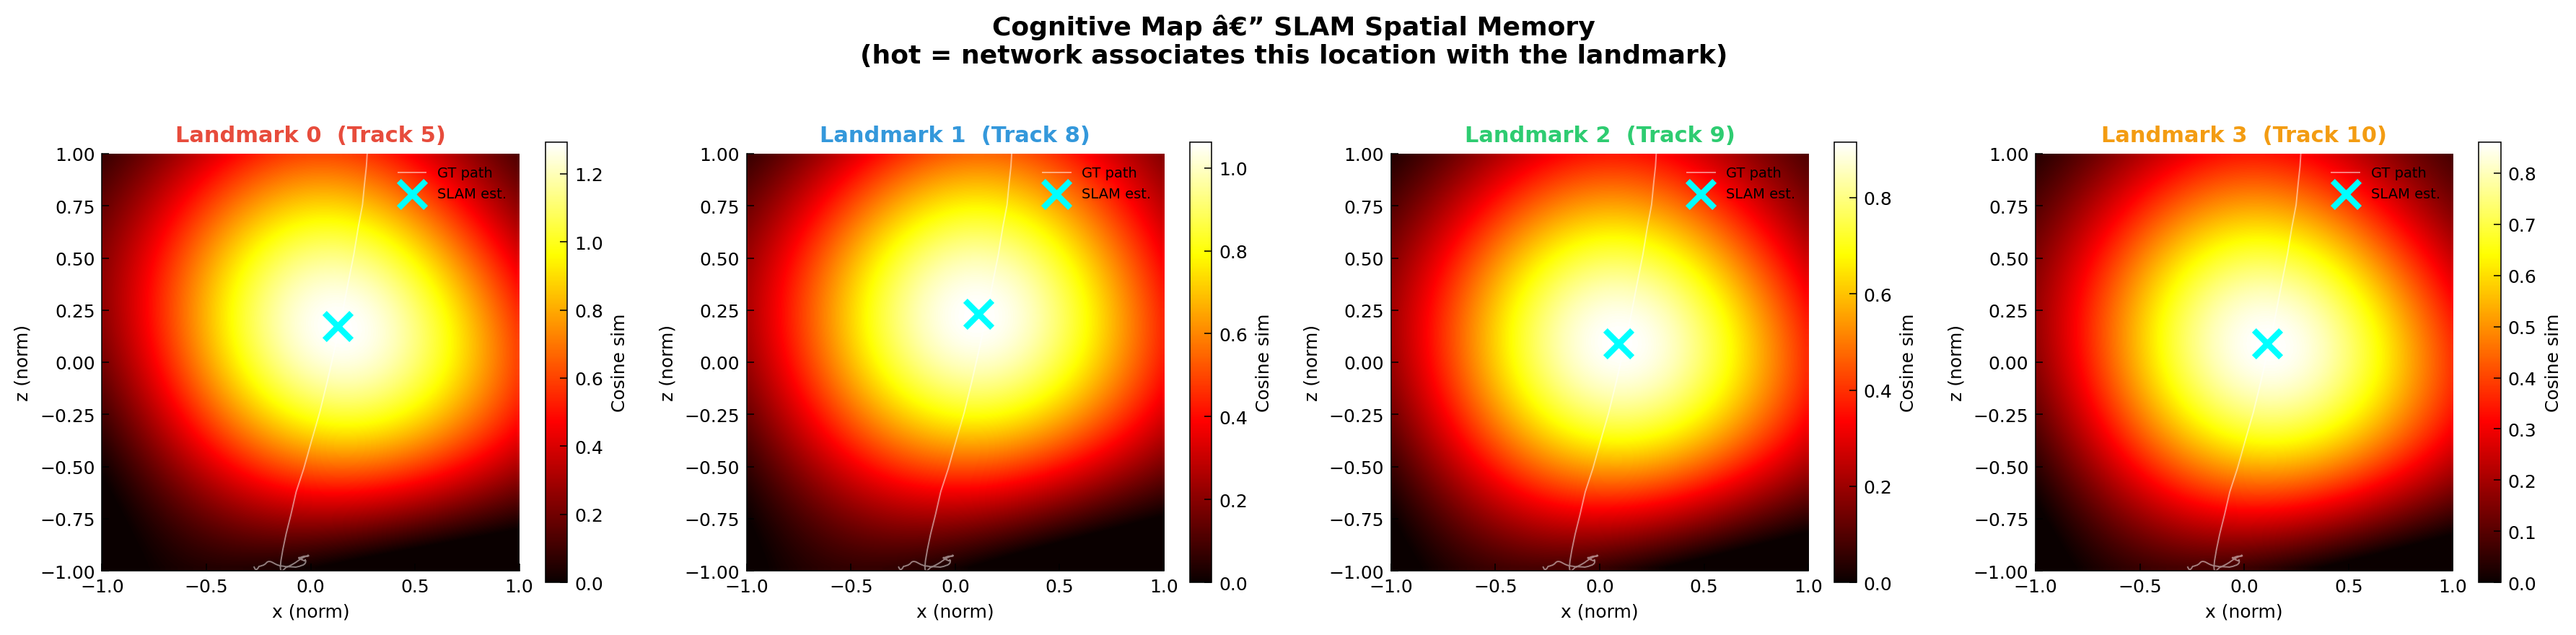

In [24]:
fig, axes = plt.subplots(1, N_LANDMARKS, figsize=(4.5 * N_LANDMARKS, 4.5))
if N_LANDMARKS == 1: axes = [axes]

for lm_i, ax in enumerate(axes):
    sims = (grid_ssps @ landmark_ssps_est[lm_i]).reshape(RES, RES)

    im = ax.imshow(sims, origin='lower', extent=[-1, 1, -1, 1],
                   cmap='hot', interpolation='bilinear', vmin=0)

    # GT path overlay
    ax.plot(path_norm[:,0], path_norm[:,1], 'w-', lw=0.7, alpha=0.5, label='GT path')

    # Estimated landmark position
    ax.scatter(*landmark_loc_est[lm_i], s=180, marker='x', color='cyan',
               zorder=6, linewidths=3, label='SLAM est.')

    ax.set_title(f'Landmark {lm_i}  (Track {top_ids[lm_i]})',
                 fontsize=11, fontweight='bold', color=COLORS[lm_i])
    ax.set_xlabel('x (norm)'); ax.set_ylabel('z (norm)')
    ax.legend(fontsize=7, loc='upper right')
    plt.colorbar(im, ax=ax, shrink=0.82, label='Cosine sim')

plt.suptitle("Cognitive Map â€” SLAM Spatial Memory\n"
             "(hot = network associates this location with the landmark)",
             fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 12 â€” Path Comparison: SLAM Estimate vs Ground Truth

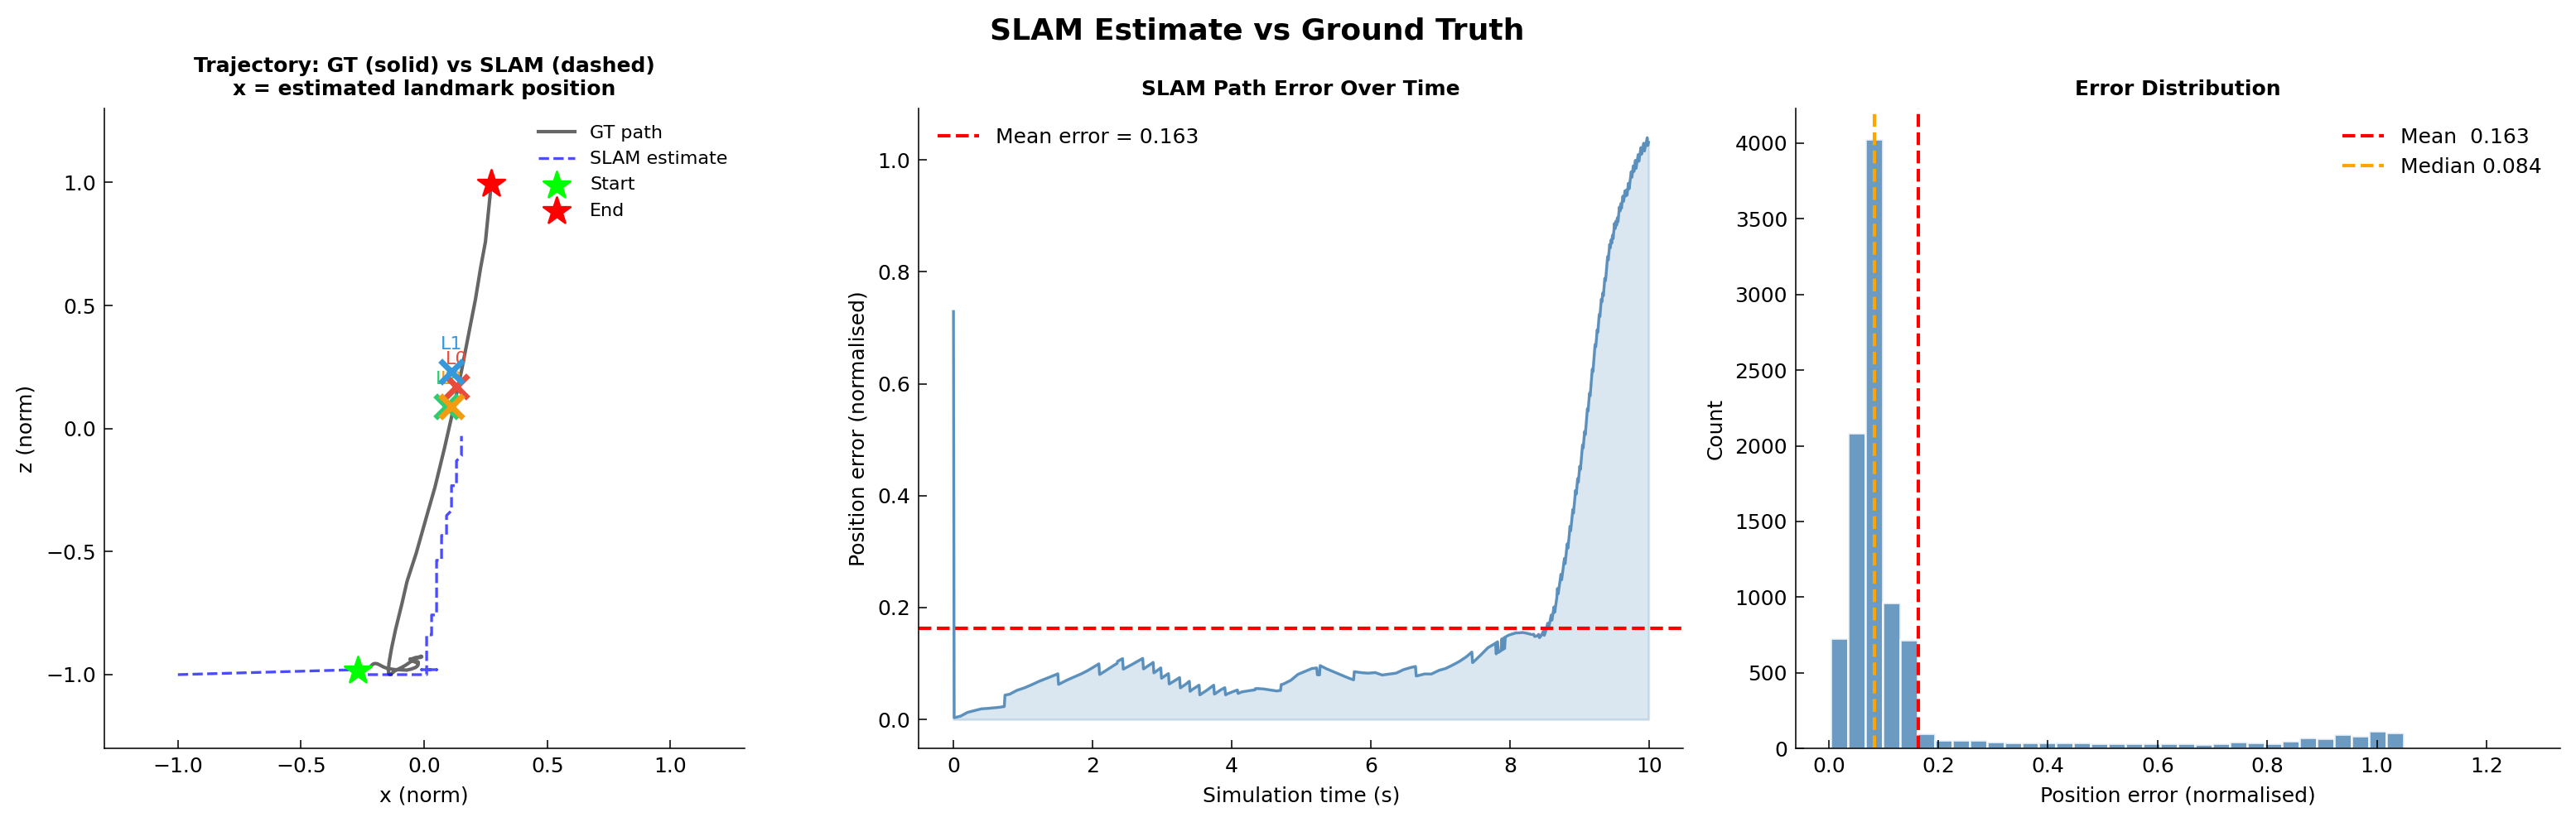

Summary statistics:
  Mean   error : 0.1632
  Median error : 0.0836
  95th pct     : 0.8753
  Max    error : 1.2711


In [25]:
# Downsample for plotting (every 10 ms)
stride = max(1, n_sim // 1000)
t_plot       = np.arange(0, n_sim, stride) * dt
slam_plot    = slam_path[::stride]
gt_plot      = path_sim[::stride]
err_plot     = slam_error[::stride]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# â”€â”€ Map view â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
axes[0].plot(gt_plot[:,0],   gt_plot[:,1],   'k-',  lw=1.5, alpha=0.6, label='GT path')
axes[0].plot(slam_plot[:,0], slam_plot[:,1], 'b--', lw=1.2, alpha=0.7, label='SLAM estimate')
axes[0].scatter(*gt_plot[0],   s=150, c='lime', marker='*', zorder=5, label='Start')
axes[0].scatter(*gt_plot[-1],  s=150, c='red',  marker='*', zorder=5, label='End')
for lm_i in range(N_LANDMARKS):
    axes[0].scatter(*landmark_loc_est[lm_i], s=100, marker='x',
                    color=COLORS[lm_i], zorder=6, linewidths=2.5)
    axes[0].annotate(f'L{lm_i}', landmark_loc_est[lm_i],
                     fontsize=8, color=COLORS[lm_i], ha='center', va='bottom',
                     xytext=(0, 8), textcoords='offset points')
axes[0].set_xlim(-1.3, 1.3); axes[0].set_ylim(-1.3, 1.3)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title('Trajectory: GT (solid) vs SLAM (dashed)\nx = estimated landmark position')
axes[0].set_xlabel('x (norm)'); axes[0].set_ylabel('z (norm)')

# â”€â”€ Error over time â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
axes[1].plot(t_plot, err_plot, color='steelblue', lw=1.2, alpha=0.85)
axes[1].fill_between(t_plot, 0, err_plot, alpha=0.2, color='steelblue')
axes[1].axhline(slam_error.mean(), c='red', ls='--', lw=1.5,
                label=f'Mean error = {slam_error.mean():.3f}')
axes[1].set_xlabel('Simulation time (s)')
axes[1].set_ylabel('Position error (normalised)')
axes[1].set_title('SLAM Path Error Over Time')
axes[1].legend(fontsize=9)

# â”€â”€ Error histogram â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
axes[2].hist(slam_error, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(slam_error.mean(),   c='red',    ls='--', lw=1.5,
                label=f'Mean  {slam_error.mean():.3f}')
axes[2].axvline(np.median(slam_error), c='orange', ls='--', lw=1.5,
                label=f'Median {np.median(slam_error):.3f}')
axes[2].set_xlabel('Position error (normalised)')
axes[2].set_ylabel('Count')
axes[2].set_title('Error Distribution')
axes[2].legend(fontsize=9)

plt.suptitle('SLAM Estimate vs Ground Truth', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Summary statistics:")
print(f"  Mean   error : {slam_error.mean():.4f}")
print(f"  Median error : {np.median(slam_error):.4f}")
print(f"  95th pct     : {np.percentile(slam_error, 95):.4f}")
print(f"  Max    error : {slam_error.max():.4f}")

---
## Section 13 â€” Full Pipeline Summary
One figure showing the entire pipeline from sensor to cognitive map.

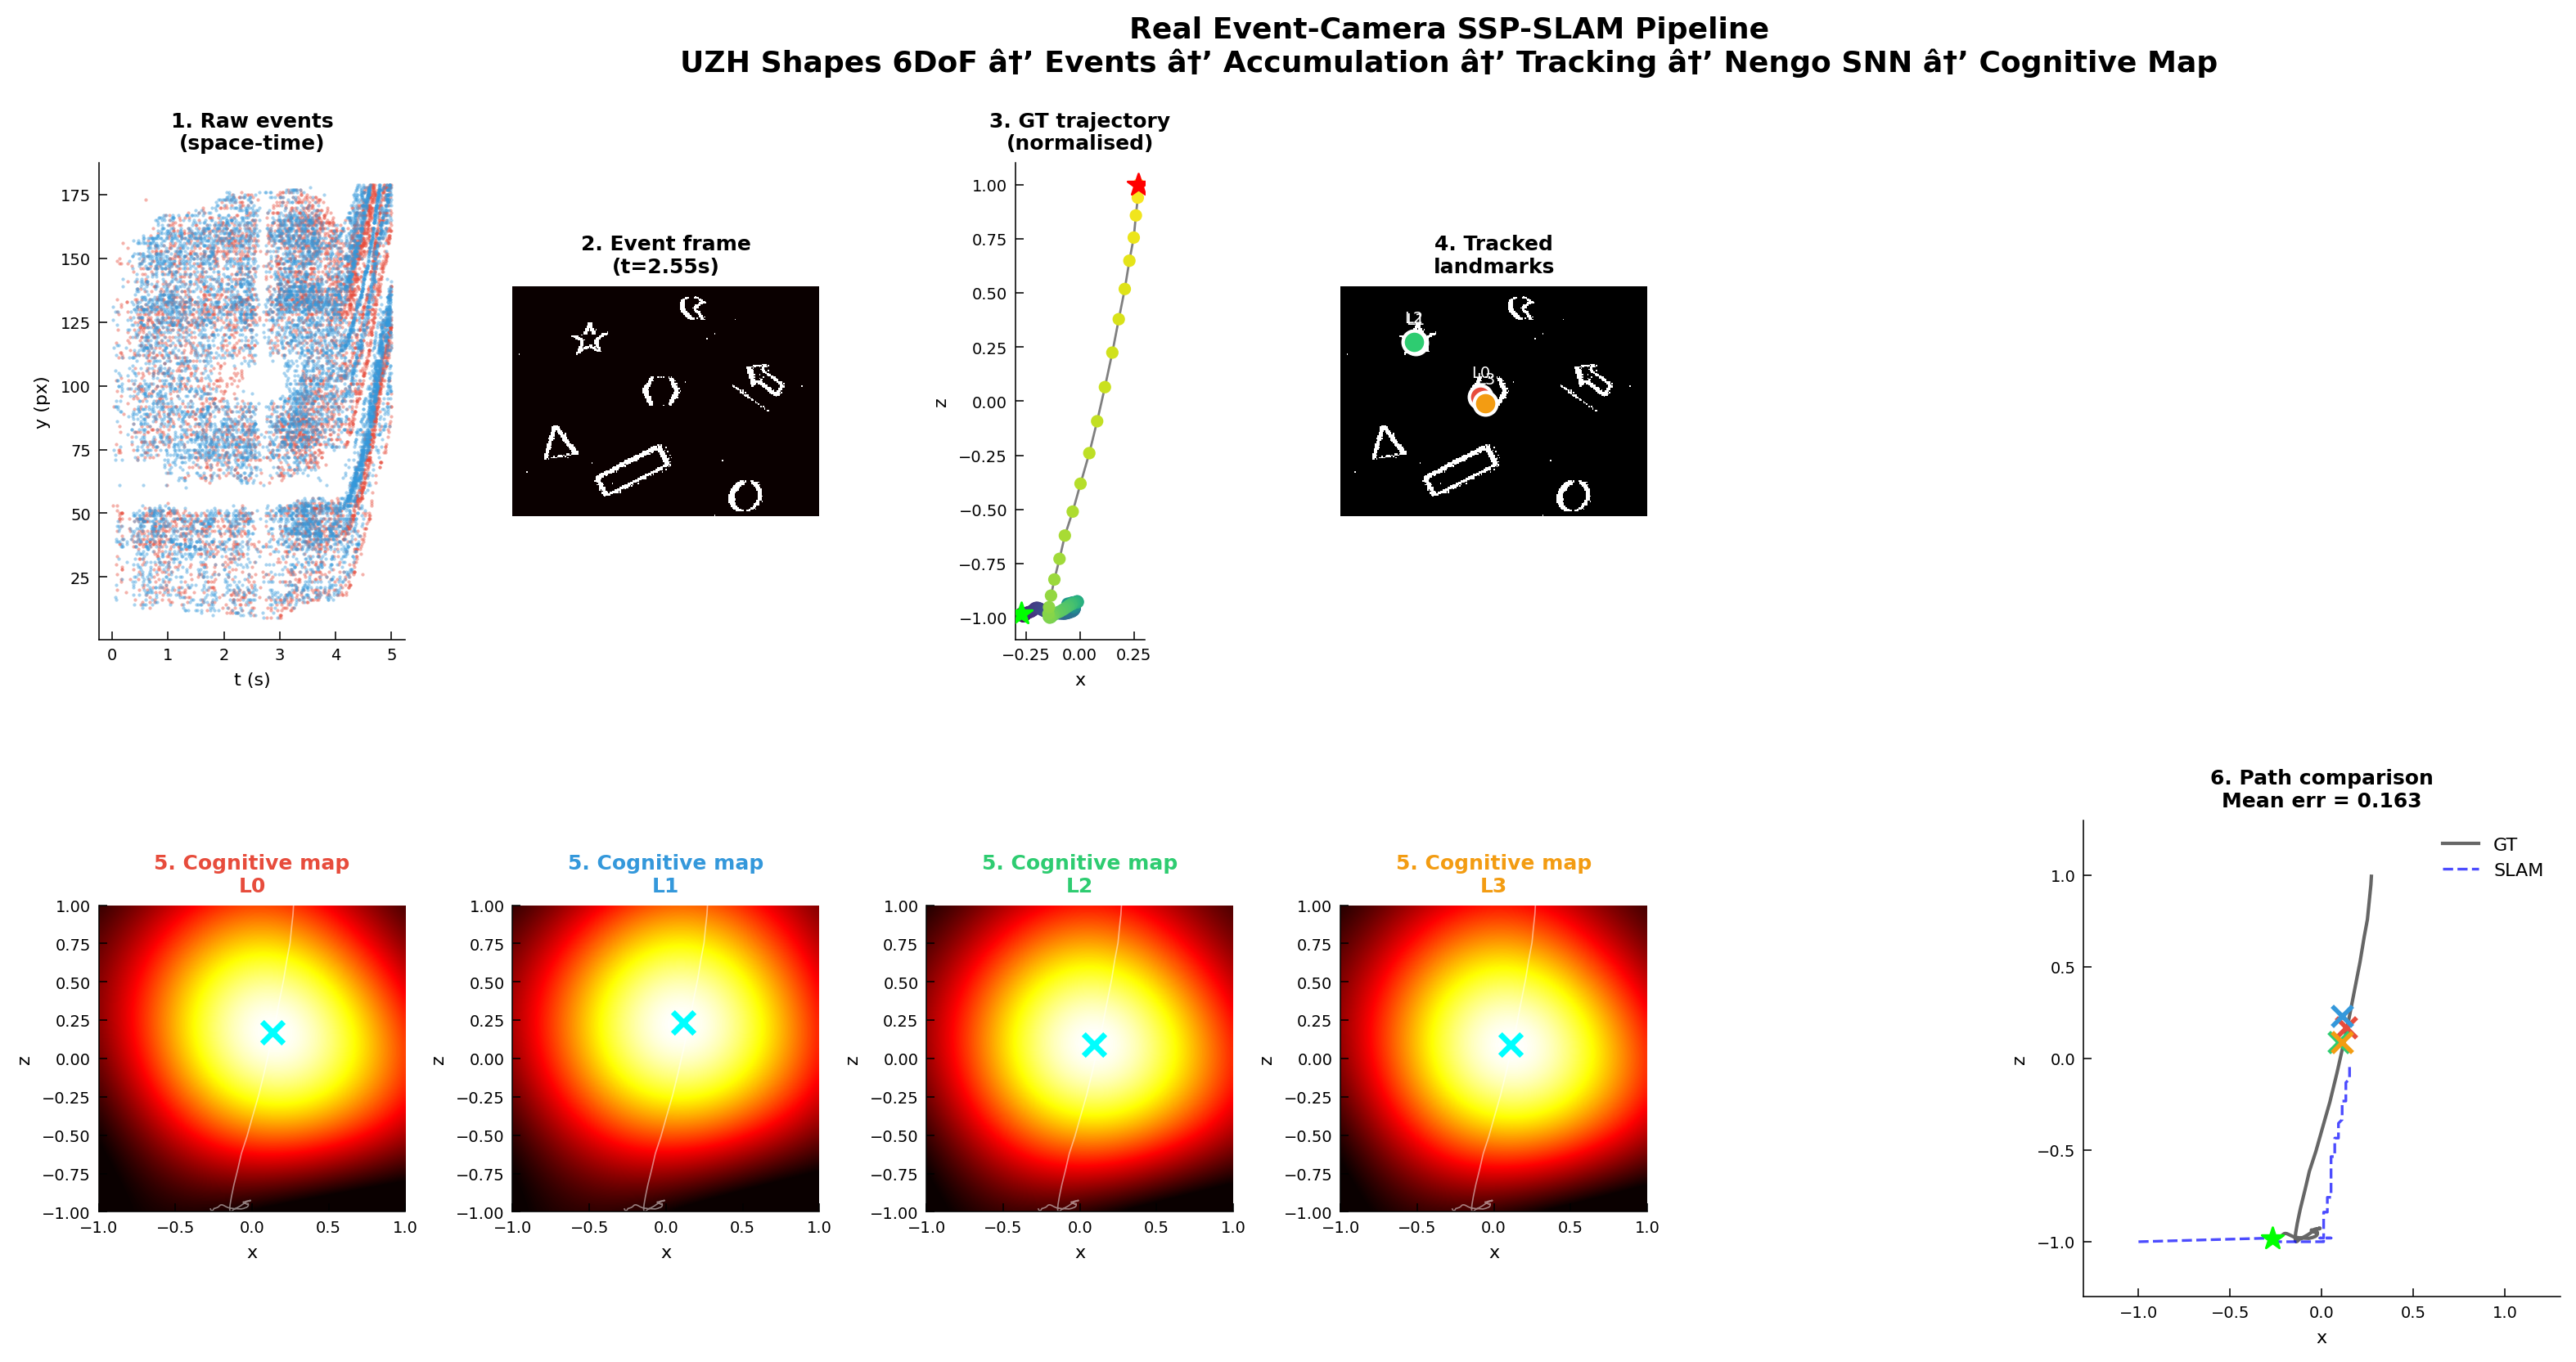

Saved to C:\Users\30068379\OneDrive - Western Sydney University\Code\Semantic-Spiking-Neural-SLAM-2023\data\shapes_6dof\real_event_slam_summary.png


In [26]:
fig = plt.figure(figsize=(22, 9))
gs  = gridspec.GridSpec(2, N_LANDMARKS + 3, figure=fig, hspace=0.38, wspace=0.35)

# â”€â”€ Row 0: Pipeline inputs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# 1. Raw event stream
ax_ev_raw = fig.add_subplot(gs[0, 0])
N_s = min(15_000, len(t_ev))
rng2 = np.random.default_rng(1)
si = np.sort(rng2.choice(len(t_ev), N_s, replace=False))
pm = p_ev[si] == 1
ax_ev_raw.scatter(t_ev[si[pm]],  y_ev[si[pm]],  s=0.3, c='#e74c3c', alpha=0.4)
ax_ev_raw.scatter(t_ev[si[~pm]], y_ev[si[~pm]], s=0.3, c='#3498db', alpha=0.4)
ax_ev_raw.set_xlabel('t (s)', fontsize=8); ax_ev_raw.set_ylabel('y (px)', fontsize=8)
ax_ev_raw.set_title('1. Raw events\n(space-time)', fontsize=9)
ax_ev_raw.tick_params(labelsize=7)

# 2. Accumulated event frame
ax_ev_fr = fig.add_subplot(gs[0, 1])
mid_fi = N_frames // 2
ax_ev_fr.imshow(event_frames[mid_fi], cmap='hot', vmin=0, vmax=255, origin='upper')
ax_ev_fr.axis('off')
ax_ev_fr.set_title(f'2. Event frame\n(t={frame_times[mid_fi]:.2f}s)', fontsize=9)

# 3. GT trajectory + path
ax_gt = fig.add_subplot(gs[0, 2])
ax_gt.plot(path_norm[:,0], path_norm[:,1], 'k-', lw=1, alpha=0.5)
sc3 = ax_gt.scatter(path_norm[:,0], path_norm[:,1],
                    c=frame_times, cmap='viridis', s=20, zorder=3)
ax_gt.scatter(*path_norm[0],  s=100, c='lime', marker='*', zorder=5)
ax_gt.scatter(*path_norm[-1], s=100, c='red',  marker='*', zorder=5)
ax_gt.set_aspect('equal')
ax_gt.set_title('3. GT trajectory\n(normalised)', fontsize=9)
ax_gt.set_xlabel('x', fontsize=8); ax_gt.set_ylabel('z', fontsize=8)
ax_gt.tick_params(labelsize=7)

# 4. Tracked landmarks
ax_lm = fig.add_subplot(gs[0, 3])
ax_lm.imshow(event_frames[mid_fi], cmap='gray', vmin=0, vmax=255, origin='upper')
for lm_i in range(N_LANDMARKS):
    if not np.any(np.isnan(track_px[mid_fi, lm_i])):
        u, v = track_px[mid_fi, lm_i]
        ax_lm.plot(u, v, 'o', color=COLORS[lm_i], ms=10,
                   mec='white', mew=1.5)
        ax_lm.annotate(f'L{lm_i}', (u, v), fontsize=7, color='white',
                       ha='center', va='bottom', xytext=(0,7),
                       textcoords='offset points')
ax_lm.axis('off')
ax_lm.set_title('4. Tracked\nlandmarks', fontsize=9)

# â”€â”€ Row 1: Outputs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# 5+. Cognitive map heatmaps
for lm_i in range(N_LANDMARKS):
    ax = fig.add_subplot(gs[1, lm_i])
    sims = (grid_ssps @ landmark_ssps_est[lm_i]).reshape(RES, RES)
    ax.imshow(sims, origin='lower', extent=[-1,1,-1,1],
              cmap='hot', interpolation='bilinear', vmin=0)
    ax.plot(path_norm[:,0], path_norm[:,1], 'w-', lw=0.6, alpha=0.5)
    ax.scatter(*landmark_loc_est[lm_i], s=90, marker='x',
               color='cyan', zorder=5, linewidths=2.5)
    ax.set_title(f'5. Cognitive map\nL{lm_i}', fontsize=9,
                 color=COLORS[lm_i], fontweight='bold')
    ax.set_xlabel('x', fontsize=8); ax.set_ylabel('z', fontsize=8)
    ax.tick_params(labelsize=7)

# Last panel: path comparison
ax_path = fig.add_subplot(gs[1, N_LANDMARKS:])
ax_path.plot(gt_plot[:,0],   gt_plot[:,1],   'k-',  lw=1.5, alpha=0.6, label='GT')
ax_path.plot(slam_plot[:,0], slam_plot[:,1], 'b--', lw=1.2, alpha=0.7, label='SLAM')
ax_path.scatter(*gt_plot[0], s=100, c='lime', marker='*', zorder=5)
for lm_i in range(N_LANDMARKS):
    ax_path.scatter(*landmark_loc_est[lm_i], s=80, marker='x',
                    color=COLORS[lm_i], zorder=6, linewidths=2)
ax_path.set_xlim(-1.3, 1.3); ax_path.set_ylim(-1.3, 1.3)
ax_path.set_aspect('equal')
ax_path.legend(fontsize=8)
ax_path.set_title(f'6. Path comparison\nMean err = {slam_error.mean():.3f}', fontsize=9)
ax_path.set_xlabel('x', fontsize=8); ax_path.set_ylabel('z', fontsize=8)
ax_path.tick_params(labelsize=7)

plt.suptitle(
    "Real Event-Camera SSP-SLAM Pipeline\n"
    "UZH Shapes 6DoF â†’ Events â†’ Accumulation â†’ Tracking â†’ Nengo SNN â†’ Cognitive Map",
    fontsize=13, fontweight='bold'
)

out_png = os.path.join(SAVE_DIR, "real_event_slam_summary.png")
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {out_png}")

In [27]:
# Save SLAM results for later re-use (skip re-running the simulation)
out_npz = os.path.join(SAVE_DIR,
    f"slam_real_events_sspdim_{ssp_dim}_lm_{N_LANDMARKS}_T_{int(T_SIM)}_seed_{SEED}.npz")
np.savez(
    out_npz,
    slam_path       = slam_path,
    path_gt         = path_sim,
    slam_error      = slam_error,
    landmark_ssps_est = landmark_ssps_est,
    landmark_loc_est  = landmark_loc_est,
    top_track_ids   = np.array(top_ids),
    ssp_dim         = ssp_dim,
    T_SIM           = T_SIM,
    elapsed_s       = elapsed,
)
print(f"Results saved to {out_npz}")
print(f"Mean path error: {slam_error.mean():.4f}  |  Simulation time: {elapsed:.1f}s")

Results saved to C:\Users\30068379\OneDrive - Western Sydney University\Code\Semantic-Spiking-Neural-SLAM-2023\data\shapes_6dof\slam_real_events_sspdim_97_lm_4_T_10_seed_0.npz
Mean path error: 0.1632  |  Simulation time: 52.7s
